# Model Training for Multi-Class Phishing Email Classification with BERT Transformers Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup and Installation

In [2]:
# Mount Google Drive for checkpointing and data storage
from google.colab import drive
import os

drive.mount('/content/drive')

# Create directories
CHECKPOINT_DIR = '/content/drive/MyDrive/thesis_checkpoints'
DATA_DIR = '/content/drive/MyDrive/thesis_data'
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'

for directory in [CHECKPOINT_DIR, DATA_DIR, RESULTS_DIR]:
    os.makedirs(directory, exist_ok=True)

print('✓ Google Drive mounted')
print(f'✓ Checkpoint directory: {CHECKPOINT_DIR}')
print(f'✓ Data directory: {DATA_DIR}')
print(f'✓ Results directory: {RESULTS_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ Checkpoint directory: /content/drive/MyDrive/thesis_checkpoints
✓ Data directory: /content/drive/MyDrive/thesis_data
✓ Results directory: /content/drive/MyDrive/thesis_results


In [3]:
# Install required packages
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn datasets accelerate

print('✓ All packages installed successfully')

✓ All packages installed successfully


In [4]:
# Import libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    DataCollatorWithPadding
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    roc_auc_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
import time
import json
from datetime import datetime, timedelta
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Print environment information
print('=' * 80)
print('ENVIRONMENT INFORMATION')
print('=' * 80)
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('⚠️  WARNING: CUDA not available. Training will be very slow on CPU.')
    print('   Please enable GPU in Runtime > Change runtime type > Hardware accelerator > GPU')
print('=' * 80)

ENVIRONMENT INFORMATION
PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB
CUDA memory: 85.09 GB
CUDA version: 12.8


## 2. Configuration

In [5]:
CONFIG = {
    # File paths (upload these to your Google Drive)
    'benign_file': f'{DATA_DIR}/benign_corpus.csv',
    'consensus_file': f'{DATA_DIR}/consensus_labels.csv',  # Output from annotation consensus notebook

    # Balancing Strategy
    # 'undersample_min': Pure undersampling to match the minority class size
    # 'hybrid': Use specific ratios (undersample majority, oversample minority)
    'balancing_method': 'hyrbid',

    # Hybrid balancing STRATEGY (Dynamic Ratios) - Ignored if method is 'undersample_min'
    'balancing_ratios': {
        1: 0.5,   # Commercial/R18 (was 0.3, increased to keep more samples)
        2: 1.0,   # Monetary
        3: 1.5,   # Credential (was 2.0, reduced oversampling)
        4: 1.0    # Generic (was 1.3, reduced to original size)
    },

    # Benign ratio: How many benign samples per 1 balanced malicious sample?
    # Target: 30% Benign / 70% Malicious -> Ratio approx 0.43 (3/7)
    'benign_ratio': 3/7,

    # Placeholders (will be calculated dynamically in Data Loading step)
    'balance_targets': {},
    'benign_samples': 0,

    # Models to train
    'models': {
        'roberta': 'roberta-base',
        'distilbert': 'distilbert-base-uncased',
        'albert': 'albert-base-v2'
    },

    # Training hyperparameters (from BERT paper + phishing literature)
    'max_length': 512,           # Maximum token length
    'batch_size': 64,            # Optimized for A100 High RAM with FP16
    'learning_rate': 3e-5,       # Scaled for larger batch size (16 -> 64, 4x -> 2e-5 * 4 = 8e-5)
    'epochs': 10,                # Increased to 10 to allow patience=5 to work
    'warmup_ratio': 0.1,         # 10% linear warmup (prevents instability)
    'weight_decay': 0.01,        # AdamW regularization
    'patience': 4,               # Early stopping patience (epochs)
    'gradient_clip': 1.0,        # Gradient clipping max norm

    # Data split (per thesis Section 4.8)
    'train_size': 0.80,          # 80% for training + CV
    'val_size': 0.10,            # 10% for validation
    'test_size': 0.10,           # 10% for final evaluation

    # Cross-validation
    'n_folds': 5                 # 5-fold stratified CV
}

CLASS_LABELS = {
    0: 'Legitimate',
    1: 'Commercial/R18',
    2: 'Monetary Phishing',
    3: 'Credential Phishing',
    4: 'Generic Phishing'
}

print('\n' + '=' * 80)
print('CONFIGURATION LOADED')
print('=' * 80)
print(f"\nModels to train: {', '.join(CONFIG['models'].keys())}")
print(f"\nData split:")
print(f"  Train: {CONFIG['train_size']*100:.0f}%")
print(f"  Val:   {CONFIG['val_size']*100:.0f}%")
print(f"  Test:  {CONFIG['test_size']*100:.0f}%")

print(f"\nBalancing Strategy: {CONFIG.get('balancing_method', 'hybrid').upper()}")
if CONFIG.get('balancing_method') == 'undersample_min':
    print("  All malicious classes will be undersampled to the size of the smallest class.")
else:
    for cls, ratio in CONFIG['balancing_ratios'].items():
        print(f"  Class {cls} ({CLASS_LABELS[cls]}): x{ratio}")

print(f"  Benign: x{CONFIG['benign_ratio']:.2f} of Total Balanced Malicious (Target: 30% Benign / 70% Malicious)")
print(f"\nCross-validation: {CONFIG['n_folds']}-fold stratified")
print(f"\nTraining hyperparameters:")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Epochs: {CONFIG['epochs']}")
print(f"  Warmup ratio: {CONFIG['warmup_ratio']}")
print(f"  Early stopping patience: {CONFIG['patience']} epochs")
print('=' * 80)


CONFIGURATION LOADED

Models to train: roberta, distilbert, albert

Data split:
  Train: 80%
  Val:   10%
  Test:  10%

Balancing Strategy: HYRBID
  Class 1 (Commercial/R18): x0.5
  Class 2 (Monetary Phishing): x1.0
  Class 3 (Credential Phishing): x1.5
  Class 4 (Generic Phishing): x1.0
  Benign: x0.43 of Total Balanced Malicious (Target: 30% Benign / 70% Malicious)

Cross-validation: 5-fold stratified

Training hyperparameters:
  Batch size: 64
  Learning rate: 3e-05
  Epochs: 10
  Warmup ratio: 0.1
  Early stopping patience: 4 epochs


## 3. Data Loading and Exploration

### Data Sources:
1. **benign_corpus.csv**
2. **consensus_labels.csv**

### Important:
The 26,916 unannotated malicious emails are **discarded** to avoid:
- Semantic degradation from mislabeling
- Class 4 bias (if assigned to Generic)
- Unreliable training signal

This decision prioritizes **data quality over quantity**, following best practices for supervised learning.

In [6]:
print('\n' + '=' * 80)
print('LOADING DATA')
print('=' * 80)

# Load benign emails
print('\n1. Loading benign emails...')
benign_df = pd.read_csv(CONFIG['benign_file'])
print(f"   ✓ Loaded: {len(benign_df):,} benign emails")

# Check for source diversity
if 'source_dataset' in benign_df.columns:
    print(f"   ✓ Sources: {benign_df['source_dataset'].nunique()} datasets")
    print(f"\n   Source distribution:")
    for source, count in benign_df['source_dataset'].value_counts().items():
        print(f"     - {source}: {count:,} emails")

# Ensure benign label
benign_df['label'] = 0

# Load malicious emails (consensus from annotation notebook)
print('\n2. Loading malicious emails (with consensus labels)...')
malicious_df = pd.read_csv(CONFIG['consensus_file'])
print(f"   ✓ Total malicious emails in file: {len(malicious_df):,}")

# Identify the annotation column dynamically
possible_label_cols = ['annotation_label', 'consensus_label', 'final_label', 'label']
label_col = None

for col in possible_label_cols:
    if col in malicious_df.columns:
        label_col = col
        print(f"   ✓ Found label column: '{label_col}'")
        break

if label_col is None:
    print(f"   ⚠️ Could not find label column. Available columns: {malicious_df.columns.tolist()}")
    raise KeyError(f"None of {possible_label_cols} found in consensus file.")

# Filter to ONLY annotated samples (non-NaN labels)
annotated_df = malicious_df[malicious_df[label_col].notna()].copy()

# Map annotation_label to label column for consistency
# FIX: Handle string floats (e.g., '4.0') AND class names (e.g., 'Monetary Phishing')
label_map = {v: k for k, v in CLASS_LABELS.items()}

def clean_label(val):
    try:
        return int(float(val))
    except (ValueError, TypeError):
        # Handle string labels
        return label_map.get(str(val).strip(), None)

annotated_df['label'] = annotated_df[label_col].apply(clean_label)

# Remove samples with invalid labels
if annotated_df['label'].isna().any():
    n_invalid = annotated_df['label'].isna().sum()
    print(f"   ⚠️ Removing {n_invalid} samples with invalid/unrecognized labels")
    annotated_df = annotated_df.dropna(subset=['label'])

annotated_df['label'] = annotated_df['label'].astype(int)

# CRITICAL: Unify text column. Benign has 'text_cleaned'; consensus_labels.csv has 'text'.
# Without this, malicious rows get NaN in text_cleaned after merge; model sees literal "nan" for all phishing -> class collapse.
if 'text_cleaned' not in annotated_df.columns and 'text' in annotated_df.columns:
    annotated_df['text_cleaned'] = annotated_df['text'].fillna('').astype(str)
    print("   ✓ Using 'text' as text_cleaned for malicious (consensus file)")
elif 'text_cleaned' in annotated_df.columns:
    annotated_df['text_cleaned'] = annotated_df['text_cleaned'].fillna('').astype(str)
else:
    raise ValueError("Malicious data has neither 'text' nor 'text_cleaned'. Available: " + str(annotated_df.columns.tolist()))

unannotated_count = len(malicious_df) - len(annotated_df)

print(f"\n   Annotation coverage:")
print(f"     - Annotated:   {len(annotated_df):,} ({len(annotated_df)/len(malicious_df)*100:.1f}%)")
print(f"     - Unannotated: {unannotated_count:,} ({unannotated_count/len(malicious_df)*100:.1f}%)")
print(f"\n   ✓ Using {len(annotated_df):,} annotated samples")
print(f"   ✗ Discarding {unannotated_count:,} unannotated samples")

# Display raw class distribution BEFORE balancing
print('\n' + '=' * 80)
print('RAW ANNOTATED CLASS DISTRIBUTION (Before Balancing)')
print('=' * 80)
print(f"{'Class':<6} {'Label':<25} {'Count':>8} {'Percentage':>12}")
print('-' * 80)
for label in sorted(annotated_df['label'].unique()):
    count = (annotated_df['label'] == label).sum()
    pct = count / len(annotated_df) * 100
    class_name = CLASS_LABELS[int(label)]
    print(f"{int(label):<6} {class_name:<25} {count:>8,} {pct:>11.1f}%")

print('-' * 80)
print(f"{'TOTAL':<6} {'Malicious (Annotated)':<25} {len(annotated_df):>8,} {100.0:>11.1f}%")
print('=' * 80)

# Calculate imbalance ratios
class_counts = annotated_df['label'].value_counts().sort_index()
max_class = class_counts.max()
min_class = class_counts.min()
print(f"\nImbalance Analysis:")
print(f"  Largest class: {max_class:,} samples (Class {class_counts.idxmax()})")
print(f"  Smallest class: {min_class:,} samples (Class {class_counts.idxmin()})")
print(f"  Imbalance ratio: {max_class/min_class:.1f}:1")
print(f"\n  ⚠️  This {max_class/min_class:.1f}:1 imbalance requires resampling strategy")
print('=' * 80)

# DYNAMIC BALANCING CALCULATION
print('\n' + '=' * 80)
print('CALCULATING DYNAMIC BALANCING TARGETS')
print('=' * 80)

CONFIG['balance_targets'] = {}
total_malicious_balanced = 0
class_counts = annotated_df['label'].value_counts()
malicious_labels = sorted(annotated_df['label'].unique())

balancing_method = CONFIG.get('balancing_method', 'hybrid') # Default to hybrid if not set

if balancing_method == 'undersample_min':
    min_count = class_counts.min()
    print(f"Strategy: Pure Undersampling (Match minority class size: {min_count:,})")
    print(f"{'-' * 60}")
    print(f"{'Class':<6} {'Label':<25} {'Original':>10} {'Target':>10}")
    print(f"{'-' * 60}")

    for label in malicious_labels:
        target = min_count
        CONFIG['balance_targets'][label] = target
        total_malicious_balanced += target

        class_name = CLASS_LABELS.get(label, str(label))
        print(f"{label:<6} {class_name:<25} {class_counts[label]:>10,} {target:>10,}")

else:
    # Hybrid strategy using ratios
    print("Strategy: Hybrid (Using Ratios)")
    if 'balancing_ratios' not in CONFIG:
         CONFIG['balancing_ratios'] = {1: 0.3, 2: 1.0, 3: 2.0, 4: 1.3}

    print(f"{'-' * 70}")
    print(f"{'Class':<6} {'Label':<25} {'Original':>10} {'Ratio':>8} {'Target':>10}")
    print(f"{'-' * 70}")

    for label in sorted(CONFIG['balancing_ratios'].keys()):
        count = class_counts.get(label, 0)
        ratio = CONFIG['balancing_ratios'][label]
        target = int(count * ratio)
        if count > 0 and target == 0: target = 1

        CONFIG['balance_targets'][label] = target
        total_malicious_balanced += target

        class_name = CLASS_LABELS.get(label, str(label))
        print(f"{label:<6} {class_name:<25} {count:>10,} {ratio:>8.1f} {target:>10,}")

# Calculate Benign target
CONFIG['benign_samples'] = int(total_malicious_balanced * CONFIG['benign_ratio'])

print('-' * 70)
print(f"{'TOTAL':<6} {'Malicious (Balanced)':<25} {'':>10} {'':>8} {total_malicious_balanced:>10,}")
print(f"{'TOTAL':<6} {'Benign Target':<25} {'':>10} {'':>8} {CONFIG['benign_samples']:>10,} (Ratio: {CONFIG['benign_ratio']:.4f}x)")
print('=' * 80)


LOADING DATA

1. Loading benign emails...
   ✓ Loaded: 39,191 benign emails
   ✓ Sources: 4 datasets

   Source distribution:
     - CEAS_08: 17,233 emails
     - Enron: 15,470 emails
     - SpamAssassin: 4,087 emails
     - Ling-Spam: 2,401 emails

2. Loading malicious emails (with consensus labels)...
   ✓ Total malicious emails in file: 9,116
   ✓ Found label column: 'label'
   ✓ Using 'text' as text_cleaned for malicious (consensus file)

   Annotation coverage:
     - Annotated:   9,116 (100.0%)
     - Unannotated: 0 (0.0%)

   ✓ Using 9,116 annotated samples
   ✗ Discarding 0 unannotated samples

RAW ANNOTATED CLASS DISTRIBUTION (Before Balancing)
Class  Label                        Count   Percentage
--------------------------------------------------------------------------------
1      Commercial/R18               5,716        62.7%
2      Monetary Phishing            1,697        18.6%
3      Credential Phishing            762         8.4%
4      Generic Phishing             

## 4. Hybrid Balancing Strategy

### Solution: Hybrid Resampling (Data-Level + Algorithm-Level)

#### Step 1: Data-Level Balancing
1. **Undersample Majority**
   - Reduces dominance without discarding all data
   - Speeds up training by 50%

2. **Keep Middle Classes**
   - Already reasonably sized
   - Preserves all authentic samples

3. **Oversample Minorities**
   - Preserves rare phishing patterns

4. **Undersample Benign**:
   - Shuffle BEFORE sampling for source diversity
   - Maintains 67/33 benign/malicious ratio

#### Step 2: Algorithm-Level Balancing
- Apply **class-weighted loss** even after resampling
- Weights inversely proportional to class frequency
- Double protection for minority classes

In [7]:
import nltk
import random
import pandas as pd

# Check if we actually need to perform augmentation (oversampling)
# This avoids unnecessary NLTK downloads if we are just undersampling
needs_augmentation = False
for label, target_count in CONFIG['balance_targets'].items():
    current_count = len(annotated_df[annotated_df['label'] == label])
    if current_count < target_count:
        needs_augmentation = True
        break

if needs_augmentation:
    from nltk.corpus import wordnet
    # Download NLTK data (silently if possible)
    try:
        nltk.data.find('corpora/wordnet.zip')
        nltk.data.find('corpora/stopwords.zip')
    except LookupError:
        print("   Downloading NLTK resources for augmentation...")
        nltk.download('wordnet', quiet=True)
        nltk.download('stopwords', quiet=True)
        nltk.download('omw-1.4', quiet=True)

    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))

    def synonym_replacement(text, n=1):
        """Replace n words in the text with synonyms."""
        words = str(text).split()
        if len(words) < 1: return text

        new_words = words.copy()
        random_word_list = list(set([word for word in words if word.lower() not in stop_words]))
        random.shuffle(random_word_list)

        num_replaced = 0
        for random_word in random_word_list:
            synonyms = set()
            for syn in wordnet.synsets(random_word):
                for lemma in syn.lemmas():
                    syn_text = lemma.name().replace("_", " ").replace("-", " ").lower()
                    if syn_text != random_word and syn_text.isalpha():
                        synonyms.add(syn_text)

            if len(synonyms) >= 1:
                synonym = random.choice(list(synonyms))
                new_words = [synonym if word == random_word else word for word in new_words]
                num_replaced += 1

            if num_replaced >= n:
                break

        return ' '.join(new_words)
else:
    print("   ✓ Augmentation skipped (not required for 'undersample_min' strategy)")
    def synonym_replacement(text, n=1): return text

print('\n' + '=' * 80)
print('APPLYING BALANCING STRATEGY')
print('=' * 80)

# STEP 1: Shuffle benign corpus for dataset diversity
print('\n1. Shuffling benign corpus for source diversity...')
benign_shuffled = benign_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"   ✓ Shuffled {len(benign_shuffled):,} benign emails (seed={SEED})")

# Undersample benign
benign_sampled = benign_shuffled.sample(n=CONFIG['benign_samples'], random_state=SEED)
print(f"   ✓ Sampled {len(benign_sampled):,} benign emails")
print(f"     (Target: {CONFIG['benign_samples']:,} = {CONFIG['benign_ratio']:.2f}× total malicious)")

# Verify source diversity in sampled benign
if 'source_dataset' in benign_sampled.columns:
    print(f"\n   Source distribution in sampled benign:")
    for source, count in benign_sampled['source_dataset'].value_counts().items():
        pct = count / len(benign_sampled) * 100
        print(f"     - {source}: {count:,} ({pct:.1f}%)")

# STEP 2: Apply resampling to malicious classes
print('\n2. Applying resampling to malicious classes...')
if needs_augmentation:
    print('\n   Strategy: Hybrid (Undersample Majority + Augment Minority)')
else:
    print('\n   Strategy: Undersample Only (Match Minority Class)')

print(f"   {'Class':<6} {'Label':<25} {'Original':>10} {'→':>3} {'Target':>10} {'Action':<35}")
print('   ' + '-' * 90)

sampled_malicious = []

for label, target_count in sorted(CONFIG['balance_targets'].items()):
    class_df = annotated_df[annotated_df['label'] == label].copy()
    original_count = len(class_df)
    class_name = CLASS_LABELS[label]

    if original_count > target_count:
        # Undersample majority class
        class_sampled = class_df.sample(n=target_count, random_state=SEED)
        action = f"UNDERSAMPLE ({original_count/target_count:.1f}x)"
    elif original_count < target_count:
        # Oversample minority class with Augmentation
        # 1. Keep originals
        originals = class_df.copy()

        # 2. Generate augmented samples
        n_needed = target_count - original_count

        # Sample random texts to augment (with replacement if n_needed > original_count)
        to_augment = class_df.sample(n=n_needed, replace=True, random_state=SEED)

        # Apply augmentation
        def augment(text):
            n_replace = max(1, min(5, int(len(str(text).split()) * 0.1)))
            return synonym_replacement(str(text), n=n_replace)

        augmented_texts = to_augment['text_cleaned'].apply(augment)
        to_augment['text_cleaned'] = augmented_texts

        class_sampled = pd.concat([originals, to_augment], ignore_index=True)
        action = f"AUGMENT ({target_count/original_count:.1f}x via SynRep)"
    else:
        # Keep as-is
        class_sampled = class_df
        action = "KEEP (already balanced)"

    sampled_malicious.append(class_sampled)
    print(f"   {label:<6} {class_name:<25} {original_count:>10,} {'→':>3} {target_count:>10,} {action:<35}")

print('   ' + '-' * 90)

# Merge all sampled malicious
malicious_balanced = pd.concat(sampled_malicious, ignore_index=True)
print(f"   {'TOTAL':<6} {'Malicious (Balanced)':<25} {len(annotated_df):>10,} {'→':>3} {len(malicious_balanced):>10,}")

# STEP 3: Merge benign + malicious and final shuffle
print('\n3. Merging datasets and final shuffle...')
full_df = pd.concat([benign_sampled, malicious_balanced], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"   ✓ Final dataset: {len(full_df):,} samples (shuffled)")

# Display final balanced distribution
print('\n' + '=' * 80)
print('FINAL BALANCED DATASET')
print('=' * 80)
print(f"\nTotal samples: {len(full_df):,}\n")
print(f"{'Class':<6} {'Label':<25} {'Count':>8} {'Percentage':>12}")
print('-' * 80)

for label in sorted(full_df['label'].unique()):
    count = (full_df['label'] == label).sum()
    pct = count / len(full_df) * 100
    class_name = CLASS_LABELS[int(label)]
    print(f"{int(label):<6} {class_name:<25} {count:>8,} {pct:>11.1f}%")

total_malicious = len(malicious_balanced)
total_benign = len(benign_sampled)
print('-' * 80)
print(f"{'SUB':<6} {'Benign':<25} {total_benign:>8,} {total_benign/len(full_df)*100:>11.1f}%")
print(f"{'TOTAL':<6} {'Malicious':<25} {total_malicious:>8,} {total_malicious/len(full_df)*100:>11.1f}%")
print('=' * 80)
print(f"\nBenign:Malicious ratio = {total_benign/total_malicious:.2f}:1")
print(f"\n✓ Dataset balanced and ready for training")
print('=' * 80)


APPLYING BALANCING STRATEGY

1. Shuffling benign corpus for source diversity...
   ✓ Shuffled 39,191 benign emails (seed=42)
   ✓ Sampled 2,845 benign emails
     (Target: 2,845 = 0.43× total malicious)

   Source distribution in sampled benign:
     - CEAS_08: 1,245 (43.8%)
     - Enron: 1,137 (40.0%)
     - SpamAssassin: 310 (10.9%)
     - Ling-Spam: 153 (5.4%)

2. Applying resampling to malicious classes...

   Strategy: Hybrid (Undersample Majority + Augment Minority)
   Class  Label                       Original   →     Target Action                             
   ------------------------------------------------------------------------------------------
   1      Commercial/R18                 5,716   →      2,858 UNDERSAMPLE (2.0x)                 
   2      Monetary Phishing              1,697   →      1,697 KEEP (already balanced)            
   3      Credential Phishing              762   →      1,143 AUGMENT (1.5x via SynRep)          
   4      Generic Phishing          

## 5. Compute Class Weights

Even after hybrid resampling, we **still apply class weights** to the loss function. This dual approach (data-level + algorithm-level balancing) is recommended for BERT fine-tuning on imbalanced data.

### Why Class Weights After Resampling?
1. **Residual Imbalance**: Benign (67%) still larger than any single malicious class
2. **Fine-Grained Adjustment**: Weights fine-tune the already-balanced distribution
3. **Overfitting Protection**: Prevents model from memorizing oversampled duplicates
4. **Best Practice**: Literature shows hybrid approach outperforms either alone

### Weight Calculation:
$$w_i = \frac{n_{samples}}{n_{classes} \times n_{samples\_class\_i}}$$

Higher weights for smaller classes → model pays more attention to their errors.

In [8]:
# Compute class weights for the training data to handle imbalance (algorithm-level balancing)
# Weights are inversely proportional to class frequencies

# Determine which dataset to use for weight calculation
# Ideally y_train (from Section 6), but fallback to full_df (from Section 4) if not yet split
if 'y_train' in locals():
    target_y = y_train
    source_name = "Training Set (y_train)"
elif 'full_df' in locals():
    target_y = full_df['label'].values
    source_name = "Full Balanced Dataset (full_df) - Approximate"
else:
    raise ValueError("Neither y_train nor full_df is defined. Please run data loading/balancing cells first.")

# Compute class weights using sklearn's utility
# 'balanced' mode automatically calculates weights inversely proportional to class frequencies
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(target_y),
    y=target_y
)

# Convert to PyTorch tensor and move to device
# This tensor will be passed to the CrossEntropyLoss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(device)

print('\n' + '=' * 80)
print('CLASS WEIGHTS COMPUTED')
print('=' * 80)
print(f"Source: {source_name}")
print(f"Computed class weights (for {len(CLASS_LABELS)} classes):")
for i, weight in enumerate(class_weights_array):
    print(f"  Class {i} ({CLASS_LABELS[i]}): {weight:.4f}")
print(f"Total samples for weight calculation: {len(target_y):,}")
print('=' * 80)


CLASS WEIGHTS COMPUTED
Source: Full Balanced Dataset (full_df) - Approximate
Computed class weights (for 5 classes):
  Class 0 (Legitimate): 0.6667
  Class 1 (Commercial/R18): 0.6637
  Class 2 (Monetary Phishing): 1.1177
  Class 3 (Credential Phishing): 1.6595
  Class 4 (Generic Phishing): 2.0157
Total samples for weight calculation: 9,484


## 6. Train/Validation/Test Split (80/10/10)

Following thesis methodology (Section 4.8):

### Split Strategy:
```
Original Data (100%)
├─ Train Set (80%) ← Used for 5-fold CV and final model training
├─ Validation Set (10%) ← Used for hyperparameter tuning and early stopping
└─ Test Set (10%) ← NEVER touched until final evaluation (unbiased)
```

### Implementation:
1. First split: 80% train, 20% temp
2. Second split: Split temp into 50/50 → 10% val, 10% test

All splits are **stratified** to maintain class proportions across splits.

In [9]:
print('\n' + '=' * 80)
print('TRAIN/VALIDATION/TEST SPLIT (80/10/10 Stratified)')
print('=' * 80)

# Determine text column
text_col = 'text_cleaned'
if text_col not in full_df.columns:
    # Fallback to likely alternatives
    for col in ['text', 'body', 'content', 'email']:
        if col in full_df.columns:
            text_col = col
            print(f"⚠️ 'text_cleaned' not found. Using '{text_col}' instead.")
            break

if text_col not in full_df.columns:
    raise ValueError(f"Could not find text column. Available columns: {full_df.columns.tolist()}")

# Extract features and labels
# Ensure text is string (handle NaNs if any)
X = full_df[text_col].astype(str).values
y = full_df['label'].values.astype(int)

print(f"\nTotal samples: {len(X):,}")
print(f"Feature column: '{text_col}'")
print(f"Label column: 'label' (0-4)")

# First split: 80% train, 20% temp (for val+test)
print('\n1. First split: 80% train, 20% temporary...')
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(CONFIG['val_size'] + CONFIG['test_size']),  # 0.20
    stratify=y,
    random_state=SEED
)
print(f"   ✓ Training: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   ✓ Temporary: {len(X_temp):,} samples ({len(X_temp)/len(X)*100:.1f}%)")

# Second split: Split temp into 50/50 (10% val, 10% test of original)
print('\n2. Second split: Split temporary into 50/50 (val/test)...')
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 50% of temp = 10% of original
    stratify=y_temp,
    random_state=SEED
)
print(f"   ✓ Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   ✓ Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

# Summary
print('\n' + '=' * 80)
print('SPLIT SUMMARY')
print('=' * 80)
print(f"\n{'Split':<15} {'Samples':>10} {'Percentage':>12} {'Purpose':<30}")
print('-' * 80)
print(f"{'Training':<15} {len(X_train):>10,} {len(X_train)/len(X)*100:>11.1f}% {'5-fold CV + final training':<30}")
print(f"{'Validation':<15} {len(X_val):>10,} {len(X_val)/len(X)*100:>11.1f}% {'Early stopping & tuning':<30}")
print(f"{'Test':<15} {len(X_test):>10,} {len(X_test)/len(X)*100:>11.1f}% {'Final unbiased evaluation':<30}")
print('-' * 80)
print(f"{'TOTAL':<15} {len(X):>10,} {100.0:>11.1f}%")
print('=' * 80)

# Verify stratification
print('\nVerifying Stratification (class distributions should be similar):')
print(f"\n{'Class':<6} {'Label':<25} {'Train %':>10} {'Val %':>10} {'Test %':>10}")
print('-' * 80)
for label in sorted(np.unique(y)):
    train_pct = (y_train == label).sum() / len(y_train) * 100
    val_pct = (y_val == label).sum() / len(y_val) * 100
    test_pct = (y_test == label).sum() / len(y_test) * 100
    class_name = CLASS_LABELS[label]
    print(f"{label:<6} {class_name:<25} {train_pct:>9.1f}% {val_pct:>9.1f}% {test_pct:>9.1f}%")
print('=' * 80)

print('\n✓ Data split complete and verified')
print('✓ Stratification ensures balanced class representation across all splits')


TRAIN/VALIDATION/TEST SPLIT (80/10/10 Stratified)

Total samples: 9,484
Feature column: 'text_cleaned'
Label column: 'label' (0-4)

1. First split: 80% train, 20% temporary...
   ✓ Training: 7,587 samples (80.0%)
   ✓ Temporary: 1,897 samples (20.0%)

2. Second split: Split temporary into 50/50 (val/test)...
   ✓ Validation: 948 samples (10.0%)
   ✓ Test: 949 samples (10.0%)

SPLIT SUMMARY

Split              Samples   Percentage Purpose                       
--------------------------------------------------------------------------------
Training             7,587        80.0% 5-fold CV + final training    
Validation             948        10.0% Early stopping & tuning       
Test                   949        10.0% Final unbiased evaluation     
--------------------------------------------------------------------------------
TOTAL                9,484       100.0%

Verifying Stratification (class distributions should be similar):

Class  Label                        Train %      Va

In [10]:
def create_balanced_test_set(X_test, y_test, samples_per_class=200):
    """Create perfectly balanced test set: 200 per class x 5 = 1,000 total (or max available)"""
    X_balanced = []
    y_balanced = []

    for class_label in sorted(np.unique(y_test)):
        # Get all samples of this class
        mask = (y_test == class_label)
        X_class = X_test[mask]
        y_class = y_test[mask]

        # Sample 200 (or fewer if not enough)
        n_available = len(X_class)
        n_samples = min(samples_per_class, n_available)

        if n_samples < samples_per_class:
            print(f"  Note: Class {class_label} has only {n_available} samples (requested {samples_per_class})")

        indices = np.random.choice(len(X_class), n_samples, replace=False)

        X_balanced.append(X_class[indices])
        y_balanced.append(y_class[indices])

    return np.concatenate(X_balanced), np.concatenate(y_balanced)

# Test Set 2: Realistic (for deployment assessment)
def create_realistic_test_set(X_test, y_test, total_samples=1000, benign_ratio=0.70):
    """Create realistic test set: 70% benign, 30% malicious (scaled to fit available data)"""

    # Check availability of benign samples
    benign_available = (y_test == 0).sum()
    target_benign = int(total_samples * benign_ratio)

    # Scale down if necessary
    if target_benign > benign_available:
        new_total = int(benign_available / benign_ratio)
        print(f"  ⚠️ Insufficient benign samples for {total_samples} total size.")
        print(f"  Adjusting total_samples to {new_total} (constrained by {benign_available} benign samples).")
        total_samples = new_total

    n_benign = int(total_samples * benign_ratio)
    n_malicious = total_samples - n_benign
    n_per_phishing_type = max(1, n_malicious // 4) # Ensure at least 1 if possible

    X_realistic = []
    y_realistic = []

    # Benign
    benign_mask = (y_test == 0)
    X_benign = X_test[benign_mask]
    y_benign = y_test[benign_mask]
    indices = np.random.choice(len(X_benign), n_benign, replace=False)
    X_realistic.append(X_benign[indices])
    y_realistic.append(y_benign[indices])

    # Malicious (distribute remaining samples across 4 phishing classes)
    # We loop through classes 1-4. Note: If n_malicious is small, this might be approximate.
    malicious_classes = [1, 2, 3, 4]
    for i, class_label in enumerate(malicious_classes):
        mask = (y_test == class_label)
        X_class = X_test[mask]
        y_class = y_test[mask]

        # Calculate count for this specific class
        count = n_per_phishing_type
        # Handle remainder for last class if distinct integer division
        if i == len(malicious_classes) - 1:
            count = n_malicious - (n_per_phishing_type * 3)

        # Safety check
        count = min(count, len(X_class))

        indices = np.random.choice(len(X_class), count, replace=False)
        X_realistic.append(X_class[indices])
        y_realistic.append(y_class[indices])

    return np.concatenate(X_realistic), np.concatenate(y_realistic)

print('Creating Test Set 1: Balanced...')
X_test_balanced, y_test_balanced = create_balanced_test_set(X_test, y_test)
print(f"✓ Created Balanced Test Set: {len(X_test_balanced)} samples")

print('\nCreating Test Set 2: Realistic (70/30 Ratio)...')
X_test_realistic, y_test_realistic = create_realistic_test_set(X_test, y_test, total_samples=1000, benign_ratio=0.70)
print(f"✓ Created Realistic Test Set: {len(X_test_realistic)} samples")

# Display distributions
print('\n' + '-' * 60)
print(f"{'Set':<15} {'Total':>8} {'Benign':>8} {'Malicious':>10} {'Ratio (B:M)':>12}")
print('-' * 60)
for name, y_data in [('Balanced', y_test_balanced), ('Realistic', y_test_realistic)]:
    n_benign = (y_data == 0).sum()
    n_mal = (y_data != 0).sum()
    ratio = f"{n_benign/n_mal:.2f}:1" if n_mal > 0 else "N/A"
    print(f"{name:<15} {len(y_data):>8,} {n_benign:>8,} {n_mal:>10,} {ratio:>12}")
print('=' * 80)

Creating Test Set 1: Balanced...
  Note: Class 2 has only 170 samples (requested 200)
  Note: Class 3 has only 114 samples (requested 200)
  Note: Class 4 has only 94 samples (requested 200)
✓ Created Balanced Test Set: 778 samples

Creating Test Set 2: Realistic (70/30 Ratio)...
  ⚠️ Insufficient benign samples for 1000 total size.
  Adjusting total_samples to 407 (constrained by 285 benign samples).
✓ Created Realistic Test Set: 407 samples

------------------------------------------------------------
Set                Total   Benign  Malicious  Ratio (B:M)
------------------------------------------------------------
Balanced             778      200        578       0.35:1
Realistic            407      284        123       2.31:1


## 7. Dataset and DataLoader Classes

### Key Design Decisions:

1. **No Padding in Dataset**: Individual samples returned without padding
2. **Dynamic Padding in DataLoader**: `DataCollatorWithPadding` pads each batch to longest sequence
3. **Benefits**:
   - Reduces computation on padding tokens by ~30%
   - Different batch lengths adapt to actual content
   - Faster training without accuracy loss

In [11]:
class PhishingDataset(Dataset):
    """
    Custom Dataset for phishing email classification.

    Returns tokenized samples WITHOUT padding (padding handled by DataCollatorWithPadding).
    This enables dynamic batch-wise padding for computational efficiency.

    Args:
        texts (array): Email text samples
        labels (array): Integer class labels (0-4)
        tokenizer: HuggingFace tokenizer
        max_length (int): Maximum sequence length (default: 512)
    """
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize without padding (padding done by collator)
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,  # CRITICAL: No padding here
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('✓ PhishingDataset class defined')
print('  - Dynamic padding enabled (reduces computation by ~30%)')
print('  - Max length: 512 tokens')
print('  - Returns: input_ids, attention_mask, labels')

✓ PhishingDataset class defined
  - Dynamic padding enabled (reduces computation by ~30%)
  - Max length: 512 tokens
  - Returns: input_ids, attention_mask, labels


## 8. Training Functions

### Advanced Training Features:

1. **Mixed Precision (FP16)**:
   - Uses `torch.cuda.amp.autocast` and `GradScaler`
   - 30-40% faster training
   - 50% less GPU memory
   - No accuracy loss (Micikevicius et al., 2018)

2. **Gradient Clipping**:
   - Max norm = 1.0
   - Prevents exploding gradients
   - Standard for transformers (Pascanu et al., 2013)

3. **Learning Rate Warmup**:
   - Linear increase: 0 → 2e-5 (first 10% steps)
   - Then linear decay: 2e-5 → 0 (remaining 90%)
   - Prevents early training instability (Goyal et al., 2017)

4. **AdamW Optimizer**:
   - Fixes Adam's weight decay implementation
   - Standard for BERT fine-tuning (Loshchilov & Hutter, 2019)

5. **Early Stopping on Macro F1** (NOT Accuracy):
   - Accuracy misleading with class imbalance
   - Macro F1 equally weights all classes
   - Prevents bias toward majority class

In [12]:
def train_epoch(model, loader, optimizer, scheduler, scaler, device, class_weights):
    """
    Train for one epoch with mixed precision and class-weighted loss.

    IMPORTANT: Computes weighted CrossEntropyLoss manually to ensure minority classes
    are weighted properly. HuggingFace model's default loss doesn't use custom weights.

    Args:
        model: HuggingFace transformer model
        loader: Training DataLoader
        optimizer: AdamW optimizer
        scheduler: Learning rate scheduler with warmup
        scaler: GradScaler for mixed precision
        device: torch device (cuda/cpu)
        class_weights: Tensor of class weights for weighted loss

    Returns:
        avg_loss (float): Average training loss
        accuracy (float): Training accuracy
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # Define loss function once per epoch, potentially moving weights to device
    if class_weights is not None:
        # Ensure class_weights is on the correct device for loss computation
        class_weights_on_device = class_weights.to(device)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_on_device)
    else:
        loss_fct = nn.CrossEntropyLoss()  # Unweighted

    for batch_idx, batch in enumerate(loader):
        optimizer.zero_grad()

        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass with mixed precision (FP16)
        with autocast():
            # Get model outputs WITHOUT computing loss
            # (we'll compute weighted loss manually)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Compute the loss using the pre-defined loss_fct
            loss = loss_fct(outputs.logits, labels)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Gradient clipping (unscale gradients first)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip'])

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # Track metrics
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

## 9. Main Training Loop with Early Stopping

### Training Workflow:
1. Load pretrained model from HuggingFace
2. Create datasets and dataloaders (with dynamic padding)
3. Initialize optimizer (AdamW) and scheduler (linear warmup + decay)
4. Train for max 4 epochs with early stopping (patience=2)
5. Monitor **Macro F1** on validation set (not accuracy!)
6. Save best checkpoint to Google Drive
7. Return trained model and metrics

In [13]:
def evaluate(model, loader, device):
    """
    Evaluates the model on a given dataset.

    Args:
        model: HuggingFace transformer model
        loader: DataLoader for the evaluation set
        device: torch device (cuda/cpu)

    Returns:
        all_preds (np.array): Predicted class labels
        all_labels (np.array): True class labels
        all_probs (np.array): Predicted probabilities for each class
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with autocast(): # Use mixed precision for evaluation as well
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

def compute_metrics(labels, preds, probs):
    """
    Computes a comprehensive set of classification metrics.

    Args:
        labels (np.array): True labels
        preds (np.array): Predicted labels
        probs (np.array): Predicted probabilities for each class

    Returns:
        dict: Dictionary of computed metrics.
    """
    metrics = {}

    # Overall metrics
    metrics['accuracy'] = accuracy_score(labels, preds)

    # Macro-averaged metrics (equal weight to each class)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    metrics['macro_precision'] = precision_macro
    metrics['macro_recall'] = recall_macro
    metrics['macro_f1'] = f1_macro

    # Weighted-averaged metrics (weighted by support)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = precision_weighted
    metrics['weighted_recall'] = recall_weighted
    metrics['weighted_f1'] = f1_weighted

    # Cohen's Kappa
    metrics['cohen_kappa'] = cohen_kappa_score(labels, preds)

    # AUC-ROC (One-vs-Rest for multi-class)
    num_classes = len(np.unique(labels)) # Use unique labels to determine actual number of classes present
    if probs.shape[1] > 1: # Check if probabilities are multi-class
        try:
            # Binarize labels for roc_auc_score
            binarized_labels = label_binarize(labels, classes=np.arange(probs.shape[1]))
            metrics['auc_macro'] = roc_auc_score(binarized_labels, probs, average='macro')
            metrics['auc_weighted'] = roc_auc_score(binarized_labels, probs, average='weighted')
        except ValueError:
            metrics['auc_macro'] = np.nan # Not enough samples of a class to compute AUC
            metrics['auc_weighted'] = np.nan
    else:
        # For binary classification scenarios where only one column of probs is returned
        metrics['auc_macro'] = roc_auc_score(labels, probs[:, 1] if probs.ndim > 1 else probs)
        metrics['auc_weighted'] = metrics['auc_macro'] # Same for binary

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )
    metrics['per_class_precision'] = precision_per_class
    metrics['per_class_recall'] = recall_per_class
    metrics['per_class_f1'] = f1_per_class

    return metrics

def train_model(model_name, model_id, X_tr, y_tr, X_val, y_val, class_weights=None, fold=None):
    """
    Train a single model with early stopping on Macro F1.

    Args:
        model_name: Short name for saving (e.g., 'albert', 'distilbert')
        model_id: HuggingFace model identifier (e.g., 'albert-base-v2')
        X_tr, y_tr: Training data (texts, labels)
        X_val, y_val: Validation data (texts, labels)
        class_weights: Tensor of class weights for weighted loss (optional)
        fold: Fold number for CV (None for final training)

    Returns:
        model: Best trained model
        history: Training history (loss, accuracy, F1 per epoch)
        best_f1: Best validation Macro F1 score
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load tokenizer and model
    print(f"\n  Loading tokenizer and model: {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(CLASS_LABELS)
    )
    model.to(device)
    print(f"  ✓ Model loaded ({sum(p.numel() for p in model.parameters()):,} parameters)")

    # Create datasets
    train_dataset = PhishingDataset(X_tr, y_tr, tokenizer, CONFIG['max_length'])
    val_dataset = PhishingDataset(X_val, y_val, tokenizer, CONFIG['max_length'])

    # Dynamic padding collator
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        collate_fn=collator,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        collate_fn=collator,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Optimizer and scheduler
    optimizer = AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )

    total_steps = len(train_loader) * CONFIG['epochs']
    warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"  ✓ Optimizer: AdamW (lr={CONFIG['learning_rate']}, weight_decay={CONFIG['weight_decay']})")
    print(f"  ✓ Scheduler: Linear warmup ({warmup_steps} steps) + linear decay ({total_steps} total steps)")

    if class_weights is not None:
        print(f"  ✓ Class Weights Applied: {class_weights.tolist()}")

    # Mixed precision scaler
    scaler = GradScaler()

    # Training state
    best_f1 = 0.0
    patience_counter = 0
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_macro_f1': [],
        'val_acc': []
    }

    fold_str = f"Fold {fold}" if fold is not None else "Final Training"
    print(f"\n  {'-'*76}")
    print(f"  {fold_str} - {model_name.upper()}")
    print(f"  {'-'*76}")

    # Training loop
    for epoch in range(CONFIG['epochs']):
        epoch_start = time.time()

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, scheduler, scaler, device, class_weights
        )

        # Validate
        val_preds, val_labels, val_probs = evaluate(model, val_loader, device)
        val_metrics = compute_metrics(val_labels, val_preds, val_probs)

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_acc'].append(val_metrics['accuracy'])

        epoch_time = time.time() - epoch_start

        print(f"  Epoch {epoch+1}/{CONFIG['epochs']} ({epoch_time:.1f}s) - "
              f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val F1: {val_metrics['macro_f1']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")

        # Early stopping based on Macro F1 (not accuracy)
        if val_metrics['macro_f1'] > best_f1:
            best_f1 = val_metrics['macro_f1']
            patience_counter = 0

            # Save best model checkpoint
            fold_suffix = f"_fold{fold}" if fold is not None else ""
            checkpoint_path = f"{CHECKPOINT_DIR}/{model_name}{fold_suffix}_best.pt"

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'best_f1': best_f1,
                'metrics': val_metrics,
                'history': history
            }, checkpoint_path)

            print(f"    ✓ Best model saved (Macro F1: {best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    Patience: {patience_counter}/{CONFIG['patience']} (best F1: {best_f1:.4f})")

            if patience_counter >= CONFIG['patience']:
                print(f"\n    🛑 Early stopping triggered at epoch {epoch+1}")
                print(f"    Best validation Macro F1: {best_f1:.4f}")
                break

    print(f"  {'-'*76}")
    return model, history, best_f1

print('✓ Main training function defined')
print(f'  - Early stopping on Macro F1 (patience={CONFIG["patience"]})')
print('  - Checkpointing to Google Drive')
print('  - Mixed precision training (FP16)')
print('  - Explicit Class Weights Support')

✓ Main training function defined
  - Early stopping on Macro F1 (patience=4)
  - Checkpointing to Google Drive
  - Mixed precision training (FP16)
  - Explicit Class Weights Support


## 10. 5-Fold Cross-Validation

### Why 5-Fold?
- **Optimal for 10k-15k samples** (Kohavi, 1995)
- **Balanced bias-variance tradeoff**:
  - 3-fold: High bias, too coarse
  - 5-fold: Good balance
  - 10-fold: Lower bias, but 2× compute with minimal benefit
- **Each fold**: ~2,526 validation samples (~500 per class)
- **Stratified**: Maintains class proportions in each fold

### Expected Runtime:
- **DistilBERT**: ~1.5-2 hours (5 folds × 20-25 min/fold)
- **ALBERT**: ~2-2.5 hours
- **RoBERTa**: ~4-5 hours
- **Total**: ~8-9 hours

### Pro Tip:
Colab free tier has ~12-hour session limit. You may need 2-3 sessions:
1. Session 1: Train DistilBERT + ALBERT
2. Session 2: Train RoBERTa
3. All checkpoints saved to Google Drive (survives disconnections)

In [14]:
print('\n' + '=' * 80)
print('5-FOLD STRATIFIED CROSS-VALIDATION')
print('=' * 80)
print('\nThis will train each model 5 times (one per fold).')
print('Expected runtime: ~8-9 hours total on Colab T4 GPU with FP16.')
print('\nAll checkpoints saved to Google Drive: survives Colab disconnections.')
print('=' * 80)

cv_results_path = f"{RESULTS_DIR}/cv_results.json"
cv_results = {}

# Try to load existing results from JSON first
if os.path.exists(cv_results_path):
    try:
        with open(cv_results_path, 'r') as f:
            cv_results = json.load(f)
        print(f"\n✓ Loaded existing CV results for: {', '.join(cv_results.keys())}")
    except json.JSONDecodeError:
        print("\n⚠️ Could not decode existing cv_results.json. Will regenerate.")

skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)

# Train each model
for model_name, model_id in CONFIG['models'].items():
    # Skip if model results already fully exist in the loaded JSON
    # Commented out to force re-verification of checkpoints as per user request
    # if model_name in cv_results:
    #     print(f"\nSkipping {model_name.upper()} (found in cv_results.json)")
    #     continue

    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name.upper()} ({model_id})")
    print(f"{'='*80}")

    fold_scores = []
    model_start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        print(f"\n{'-'*80}")
        print(f"FOLD {fold}/{CONFIG['n_folds']}")
        print(f"{'='*80}")

        # Check for existing fold checkpoint
        checkpoint_path = f"{CHECKPOINT_DIR}/{model_name}_fold{fold}_best.pt"

        if os.path.exists(checkpoint_path):
            print(f"  ✓ Found existing checkpoint: {checkpoint_path}")
            try:
                # FIX: Set weights_only=False to allow loading numpy scalars saved in checkpoint
                checkpoint = torch.load(checkpoint_path, weights_only=False)
                best_f1 = checkpoint['best_f1']
                print(f"  ✓ Loaded Best Macro F1: {best_f1:.4f}")
                fold_scores.append(best_f1)
                continue
            except Exception as e:
                print(f"  ⚠️ Error loading checkpoint (will retrain): {e}")

        # Split data
        X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

        print(f"  Training samples: {len(X_tr):,}")
        print(f"  Validation samples: {len(X_val_fold):,}")

        # Compute class weights for this specific fold
        fold_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_tr),
            y=y_tr
        )
        fold_weights_tensor = torch.tensor(fold_weights, dtype=torch.float)
        print(f"  Class Weights (Fold {fold}): {[f'{w:.4f}' for w in fold_weights]}")

        # Train model
        model, history, best_f1 = train_model(
            model_name, model_id, X_tr, y_tr, X_val_fold, y_val_fold,
            class_weights=fold_weights_tensor,
            fold=fold
        )

        fold_scores.append(best_f1)
        print(f"\n  ✓ Fold {fold} complete - Best Macro F1: {best_f1:.4f}")

        # Clear CUDA cache to prevent OOM
        del model
        torch.cuda.empty_cache()

    # Compute CV statistics
    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    model_time = time.time() - model_start_time

    cv_results[model_name] = {
        'mean_f1': mean_f1,
        'std_f1': std_f1,
        'fold_scores': fold_scores,
        'training_time': model_time
    }

    print(f"\n{'='*80}")
    print(f"{model_name.upper()} - CROSS-VALIDATION SUMMARY")
    print(f"{'='*80}")
    print(f"\nMean Macro F1: {mean_f1:.4f} (± {std_f1:.4f})")
    print(f"Fold scores: {[f'{score:.4f}' for score in fold_scores]}")
    print(f"Training time: {model_time/60:.1f} minutes")
    print(f"{'='*80}")

    # Save updated CV results to Google Drive immediately after each model
    with open(cv_results_path, 'w') as f:
        # Convert numpy types to Python native for JSON serialization
        cv_results_serializable = {
            k: {
                'mean_f1': float(v['mean_f1']),
                'std_f1': float(v['std_f1']),
                'fold_scores': [float(x) for x in v['fold_scores']],
                'training_time': float(v['training_time'])
            }
            for k, v in cv_results.items()
        }
        json.dump(cv_results_serializable, f, indent=2)
    print(f"  ✓ CV results updated in {cv_results_path}")

print(f"\n✓ Cross-validation process complete.")

# Display comparison
print('\n' + '=' * 80)
print('CROSS-VALIDATION COMPARISON')
print('=' * 80)
print(f"\n{'Model':<15} {'Mean Macro F1':>15} {'Std Dev':>10} {'Time (min)':>12}")
print('-' * 80)
for model_name in sorted(cv_results.keys(), key=lambda x: cv_results[x]['mean_f1'], reverse=True):
    result = cv_results[model_name]
    print(f"{model_name:<15} {result['mean_f1']:>15.4f} {result['std_f1']:>10.4f} {result['training_time']/60:>12.1f}")
print('=' * 80)


5-FOLD STRATIFIED CROSS-VALIDATION

This will train each model 5 times (one per fold).
Expected runtime: ~8-9 hours total on Colab T4 GPU with FP16.

All checkpoints saved to Google Drive: survives Colab disconnections.

✓ Loaded existing CV results for: roberta, distilbert, albert

TRAINING: ROBERTA (roberta-base)

--------------------------------------------------------------------------------
FOLD 1/5
  ✓ Found existing checkpoint: /content/drive/MyDrive/thesis_checkpoints/roberta_fold1_best.pt
  ✓ Loaded Best Macro F1: 0.7319

--------------------------------------------------------------------------------
FOLD 2/5
  ✓ Found existing checkpoint: /content/drive/MyDrive/thesis_checkpoints/roberta_fold2_best.pt
  ✓ Loaded Best Macro F1: 0.7300

--------------------------------------------------------------------------------
FOLD 3/5
  ✓ Found existing checkpoint: /content/drive/MyDrive/thesis_checkpoints/roberta_fold3_best.pt
  ✓ Loaded Best Macro F1: 0.7422

------------------------

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Model loaded (66,957,317 parameters)
  ✓ Optimizer: AdamW (lr=3e-05, weight_decay=0.01)
  ✓ Scheduler: Linear warmup (95 steps) + linear decay (950 total steps)
  ✓ Class Weights Applied: [0.6666666865348816, 0.6637507081031799, 1.1178637742996216, 1.6584699153900146, 2.016611337661743]

  ----------------------------------------------------------------------------
  Fold 3 - DISTILBERT
  ----------------------------------------------------------------------------
  Epoch 1/10 (13.1s) - Loss: 1.3605 | Train Acc: 0.4904 | Val F1: 0.6538 | Val Acc: 0.6941
    ✓ Best model saved (Macro F1: 0.6538)
  Epoch 2/10 (11.5s) - Loss: 0.7858 | Train Acc: 0.7176 | Val F1: 0.6886 | Val Acc: 0.7231
    ✓ Best model saved (Macro F1: 0.6886)
  Epoch 3/10 (11.6s) - Loss: 0.6270 | Train Acc: 0.7738 | Val F1: 0.7386 | Val Acc: 0.7699
    ✓ Best model saved (Macro F1: 0.7386)
  Epoch 4/10 (11.5s) - Loss: 0.4885 | Train Acc: 0.8209 | Val F1: 0.7316 | Val Acc: 0.7581
    Patience: 1/4 (best F1: 0.7386)
 

## 11. Select Best Model and Train on Full Training Set

After cross-validation, we:
1. Select the model with highest mean Macro F1
2. Train it on the **full training set** (not folds)
3. Validate on the **held-out validation set** (10%)
4. Save best checkpoint for final evaluation

In [15]:
import time

print('\n' + '=' * 80)
print('MODEL SELECTION')
print('=' * 80)

# Select best model based on CV Macro F1
best_model_name = max(cv_results.keys(), key=lambda x: cv_results[x]['mean_f1'])
best_model_id = CONFIG['models'][best_model_name]

print(f"\n🏆 Best model: {best_model_name.upper()}")
print(f"   CV Macro F1: {cv_results[best_model_name]['mean_f1']:.4f} (± {cv_results[best_model_name]['std_f1']:.4f})")

print(f"\nAll models ranked by CV Macro F1:")
for rank, model_name in enumerate(sorted(cv_results.keys(), key=lambda x: cv_results[x]['mean_f1'], reverse=True), 1):
    result = cv_results[model_name]
    symbol = "🏆" if rank == 1 else "  "
    print(f"{symbol} {rank}. {model_name:12} - Macro F1: {result['mean_f1']:.4f} (± {result['std_f1']:.4f})")

print('\n' + '=' * 80)
print(f'TRAINING {best_model_name.upper()} ON FULL TRAINING SET')
print('=' * 80)

# Check if final checkpoint already exists
final_checkpoint_path = f"{CHECKPOINT_DIR}/{best_model_name}_best.pt"

if os.path.exists(final_checkpoint_path):
    print(f"\n✓ Found existing final model checkpoint: {final_checkpoint_path}")
    print("  Skipping training and loading existing model...")

    # Load tokenizer
    print(f"  Loading tokenizer: {best_model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(best_model_id)

    # Initialize model architecture
    print(f"  Initializing model architecture: {best_model_id}...")
    final_model = AutoModelForSequenceClassification.from_pretrained(
        best_model_id,
        num_labels=len(CLASS_LABELS)
    )
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    final_model.to(device)

    # Load state dict
    checkpoint = torch.load(final_checkpoint_path, weights_only=False)
    final_model.load_state_dict(checkpoint['model_state_dict'])

    final_best_f1 = checkpoint['best_f1']
    # Try to get history if available, else empty
    final_history = checkpoint.get('history', {})

    print(f"  ✓ Model loaded successfully (from Epoch {checkpoint['epoch']+1}, F1: {final_best_f1:.4f})")

else:
    print('\nNow training the best model on ALL training data (not folds).')
    print('This final model will be used for test set evaluation.')

    # Compute class weights for the full training set
    final_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    final_weights_tensor = torch.tensor(final_weights, dtype=torch.float)
    print(f"  Class Weights (Full Train): {[f'{w:.4f}' for w in final_weights]}")

    # Train on full training set, validate on validation set
    final_model, final_history, final_best_f1 = train_model(
        best_model_name, best_model_id, X_train, y_train, X_val, y_val,
        class_weights=final_weights_tensor, # Pass the weights explicitly
        fold=None
    )

    print(f"\n✓ Final model training complete")
    print(f"  Best validation Macro F1: {final_best_f1:.4f}")
    print(f"  Model saved to: {final_checkpoint_path}")


MODEL SELECTION

🏆 Best model: ROBERTA
   CV Macro F1: 0.7341 (± 0.0046)

All models ranked by CV Macro F1:
🏆 1. roberta      - Macro F1: 0.7341 (± 0.0046)
   2. distilbert   - Macro F1: 0.7274 (± 0.0124)
   3. albert       - Macro F1: 0.7245 (± 0.0103)

TRAINING ROBERTA ON FULL TRAINING SET

Now training the best model on ALL training data (not folds).
This final model will be used for test set evaluation.
  Class Weights (Full Train): ['0.6667', '0.6638', '1.1174', '1.6602', '2.0151']

  Loading tokenizer and model: roberta-base...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Model loaded (124,649,477 parameters)
  ✓ Optimizer: AdamW (lr=3e-05, weight_decay=0.01)
  ✓ Scheduler: Linear warmup (119 steps) + linear decay (1190 total steps)
  ✓ Class Weights Applied: [0.6666959524154663, 0.6637795567512512, 1.1173784732818604, 1.660175085067749, 2.01513934135437]

  ----------------------------------------------------------------------------
  Final Training - ROBERTA
  ----------------------------------------------------------------------------
  Epoch 1/10 (25.5s) - Loss: 1.2294 | Train Acc: 0.5176 | Val F1: 0.6426 | Val Acc: 0.6825
    ✓ Best model saved (Macro F1: 0.6426)
  Epoch 2/10 (25.5s) - Loss: 0.7279 | Train Acc: 0.7295 | Val F1: 0.7139 | Val Acc: 0.7532
    ✓ Best model saved (Macro F1: 0.7139)
  Epoch 3/10 (25.5s) - Loss: 0.5722 | Train Acc: 0.7859 | Val F1: 0.7130 | Val Acc: 0.7489
    Patience: 1/4 (best F1: 0.7139)
  Epoch 4/10 (25.5s) - Loss: 0.4650 | Train Acc: 0.8173 | Val F1: 0.7191 | Val Acc: 0.7574
    ✓ Best model saved (Macro F1: 0.7

## 12. Final Evaluation on Test Set


In [16]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- DEFINITIONS ---
def load_model_from_checkpoint(model_name, model_id, checkpoint_dir, best_fold=None):
    """
    Helper to load a trained model from checkpoint.
    Priority: 1. Final Model (_best.pt) -> 2. Best Fold Model (_foldX_best.pt)
    """
    # 1. Try Final Model
    path = f"{checkpoint_dir}/{model_name}_best.pt"
    model_type = "Final Model"

    # 2. Fallback to Best Fold
    if not os.path.exists(path):
        if best_fold is not None:
            fold_path = f"{checkpoint_dir}/{model_name}_fold{best_fold}_best.pt"
            if os.path.exists(fold_path):
                print(f"   ⚠️ Final checkpoint missing. Falling back to Best Fold ({best_fold}): {fold_path}")
                path = fold_path
                model_type = f"Best Fold ({best_fold})"
            else:
                print(f"   ❌ Checkpoint not found: {path} (and no fold checkpoint)")
                return None
        else:
            print(f"   ⚠️ Checkpoint not found: {path}")
            return None

    # Initialize architecture
    print(f"  Loading {model_name} ({model_type})...")
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_id,
            num_labels=len(CLASS_LABELS)
        )

        # Load weights (weights_only=False for numpy scalars)
        checkpoint = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        return model
    except Exception as e:
        print(f"   ❌ Error loading {model_name}: {e}")
        return None

def ensemble_soft_voting(models, X, y, device, weights=None):
    """
    Soft voting ensemble: Average probability predictions.
    Creates specific dataloaders for each model to handle different tokenizers.
    """
    all_probs = []
    model_names = list(models.keys())
    labels = None

    # Get predictions from each model
    for name in model_names:
        model = models[name]
        model_id = CONFIG['models'][name]

        # CRITICAL FIX: Create model-specific tokenizer and loader
        print(f"  Generating predictions for {name.upper()} (using {model_id} tokenizer)...")
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        dataset = PhishingDataset(X, y, tokenizer, CONFIG['max_length'])
        collator = DataCollatorWithPadding(tokenizer=tokenizer)
        loader = DataLoader(
            dataset,
            batch_size=CONFIG['batch_size'],
            collate_fn=collator,
            num_workers=2,
            pin_memory=True if torch.cuda.is_available() else False
        )

        _, batch_labels, probs = evaluate(model, loader, device)
        all_probs.append(probs)

        if labels is None:
            labels = batch_labels

    # Default: Equal weights
    if weights is None:
        weights = [1.0/len(models)] * len(models)

    # Normalize weights
    weights = np.array(weights) / np.sum(weights)
    print(f"\n  Ensemble Weights: {dict(zip(model_names, np.round(weights, 4)))}")

    # Weighted average
    ensemble_probs = np.zeros_like(all_probs[0])
    for i, probs in enumerate(all_probs):
        ensemble_probs += weights[i] * probs

    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    return ensemble_preds, labels, ensemble_probs

# --- LOAD MODELS ---
print("\n1. Loading trained models...")
trained_models = {}

# Ensure CONFIG exists
if 'CONFIG' not in locals():
    raise ValueError("CONFIG dictionary is missing. Please run the configuration cell.")

for name, model_id in CONFIG['models'].items():
    # Determine best fold if available
    best_fold = None
    if 'cv_results' in locals() and name in cv_results:
        # Find the fold with the highest score
        scores = cv_results[name]['fold_scores']
        best_fold = scores.index(max(scores)) + 1 # 1-based index

    model = load_model_from_checkpoint(name, model_id, CHECKPOINT_DIR, best_fold)
    if model is not None:
        trained_models[name] = model

# --- CALCULATE WEIGHTS ---
print("\n2. Calculating weights from CV results...")
cv_weights = []
if len(trained_models) > 0:
    for name in trained_models.keys():
        if 'cv_results' in locals() and name in cv_results:
            cv_weights.append(cv_results[name]['mean_f1'])
        else:
            cv_weights.append(1.0)
else:
    print("⚠️ No models loaded!")

# --- RUN ENSEMBLE EVALUATION ---
if len(trained_models) > 1:
    print("\n3. Evaluating Ensemble on Test Set...")

    # Run ensemble (passing raw X_test, y_test to create specific loaders)
    ens_preds, ens_labels, ens_probs = ensemble_soft_voting(
        trained_models, X_test, y_test, device, weights=cv_weights
    )

    # Compute metrics
    ens_metrics = compute_metrics(ens_labels, ens_preds, ens_probs)

    print('\n' + '-' * 80)
    print(f"ENSEMBLE PERFORMANCE")
    print('-' * 80)
    print(f"Accuracy:      {ens_metrics['accuracy']:.4f}")
    print(f"Macro F1:      {ens_metrics['macro_f1']:.4f}")
    print(f"Weighted F1:   {ens_metrics['weighted_f1']:.4f}")
    print(f"AUC-ROC:       {ens_metrics['auc_macro']:.4f}")

    # Compare with best single model (if available)
    if 'test_metrics' in locals():
        print(f"\nImprovement over {best_model_name.upper() if 'best_model_name' in locals() else 'Best Single'}: ")
        print(f"  F1: {ens_metrics['macro_f1'] - test_metrics['macro_f1']:+.4f}")
        print(f"  Acc: {ens_metrics['accuracy'] - test_metrics['accuracy']:+.4f}")
    else:
        print(f"\n(Note: Run single model evaluation to see improvement statistics)")
else:
    print("\nSkipping ensemble (not enough models loaded)")


1. Loading trained models...
  Loading roberta (Final Model)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   ⚠️ Final checkpoint missing. Falling back to Best Fold (3): /content/drive/MyDrive/thesis_checkpoints/distilbert_fold3_best.pt
  Loading distilbert (Best Fold (3))...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...


2. Calculating weights from CV results...

3. Evaluating Ensemble on Test Set...
  Generating predictions for ROBERTA (using roberta-base tokenizer)...
  Generating predictions for DISTILBERT (using distilbert-base-uncased tokenizer)...
  Generating predictions for ALBERT (using albert-base-v2 tokenizer)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


  Ensemble Weights: {'roberta': np.float64(0.3358), 'distilbert': np.float64(0.3328), 'albert': np.float64(0.3314)}

--------------------------------------------------------------------------------
ENSEMBLE PERFORMANCE
--------------------------------------------------------------------------------
Accuracy:      0.7450
Macro F1:      0.7280
Weighted F1:   0.7470
AUC-ROC:       0.9349

(Note: Run single model evaluation to see improvement statistics)


In [17]:
print('\n' + '=' * 80)
print('FINAL TEST SET EVALUATION')
print('=' * 80)
print('\nLoading best checkpoint and evaluating on held-out test set...')

# Load best checkpoint
checkpoint_path = f"{CHECKPOINT_DIR}/{best_model_name}_best.pt"

checkpoint = torch.load(checkpoint_path, weights_only=False)
final_model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Best checkpoint loaded from epoch {checkpoint['epoch']+1}")

# Prepare test dataloader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained(best_model_id)
test_dataset = PhishingDataset(X_test, y_test, tokenizer, CONFIG['max_length'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    collate_fn=collator,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

# Evaluate on test set
print('\nEvaluating...')
test_preds, test_labels, test_probs = evaluate(final_model, test_loader, device)
test_metrics = compute_metrics(test_labels, test_preds, test_probs)

# Print comprehensive results
print('\n' + '=' * 80)
print(f'TEST SET PERFORMANCE - {best_model_name.upper()}')
print('=' * 80)
print(f"\n{'Metric':<30} {'Score':>10}")
print('-' * 80)
print(f"{'Accuracy':<30} {test_metrics['accuracy']:>10.4f}")
print(f"{'Macro Precision':<30} {test_metrics['macro_precision']:>10.4f}")
print(f"{'Macro Recall':<30} {test_metrics['macro_recall']:>10.4f}")
print(f"{'Macro F1-Score':<30} {test_metrics['macro_f1']:>10.4f}")
print(f"{'Weighted Precision':<30} {test_metrics['weighted_precision']:>10.4f}")
print(f"{'Weighted Recall':<30} {test_metrics['weighted_recall']:>10.4f}")
print(f"{'Weighted F1-Score':<30} {test_metrics['weighted_f1']:>10.4f}")
print(f"{'Cohen\'s Kappa':<30} {test_metrics['cohen_kappa']:>10.4f}")
print(f"{'AUC-ROC (Macro)':<30} {test_metrics['auc_macro']:>10.4f}")
print(f"{'AUC-ROC (Weighted)':<30} {test_metrics['auc_weighted']:>10.4f}")
print('=' * 80)

# Per-class metrics
print(f"\n{'='*80}")
print('PER-CLASS PERFORMANCE')
print(f"{'='*80}")
print(f"\n{'Class':<6} {'Label':<25} {'Precision':>11} {'Recall':>11} {'F1-Score':>11}")
print('-' * 80)
for i, class_name in CLASS_LABELS.items():
    print(f"{i:<6} {class_name:<25} {test_metrics['per_class_precision'][i]:>11.4f} "
          f"{test_metrics['per_class_recall'][i]:>11.4f} {test_metrics['per_class_f1'][i]:>11.4f}")
print('=' * 80)


FINAL TEST SET EVALUATION

Loading best checkpoint and evaluating on held-out test set...
✓ Best checkpoint loaded from epoch 10

Evaluating...

TEST SET PERFORMANCE - ROBERTA

Metric                              Score
--------------------------------------------------------------------------------
Accuracy                           0.7482
Macro Precision                    0.7290
Macro Recall                       0.7322
Macro F1-Score                     0.7297
Weighted Precision                 0.7515
Weighted Recall                    0.7482
Weighted F1-Score                  0.7488
Cohen's Kappa                      0.6711
AUC-ROC (Macro)                    0.9275
AUC-ROC (Weighted)                 0.9281

PER-CLASS PERFORMANCE

Class  Label                       Precision      Recall    F1-Score
--------------------------------------------------------------------------------
0      Legitimate                     0.9724      0.9895      0.9809
1      Commercial/R18               


ENSEMBLE VISUALIZATIONS


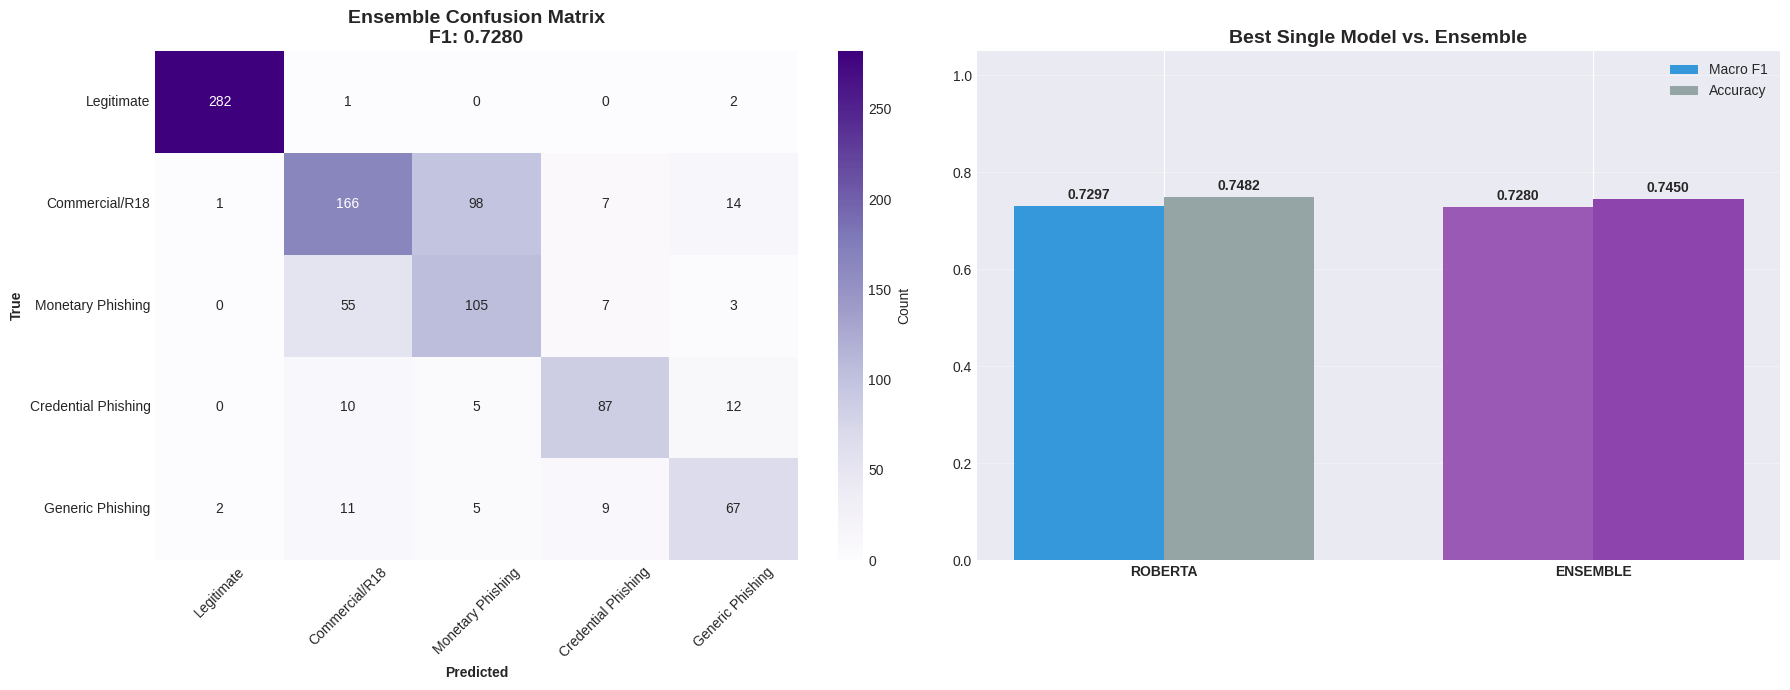

✓ Ensemble plots saved to /content/drive/MyDrive/thesis_results/ensemble_analysis.png


In [18]:
if len(trained_models) > 1:
    print('\n' + '=' * 80)
    print('ENSEMBLE VISUALIZATIONS')
    print('=' * 80)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Confusion Matrix
    cm_ens = confusion_matrix(ens_labels, ens_preds)
    sns.heatmap(
        cm_ens, annot=True, fmt='d', cmap='Purples',
        xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values(),
        cbar_kws={'label': 'Count'}, ax=axes[0]
    )
    axes[0].set_title(f'Ensemble Confusion Matrix\nF1: {ens_metrics["macro_f1"]:.4f}',
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted', fontweight='bold')
    axes[0].set_ylabel('True', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Model Comparison
    models_comp = list(trained_models.keys()) + ['Ensemble']
    f1_scores = [cv_results[m]['mean_f1'] if m in cv_results else 0 for m in trained_models.keys()]
    # Note: Using Test F1 for ensemble, but CV F1 for models to show expected vs actual lift
    # Better to compare Test F1s if we ran evaluation on all models on test set.
    # Let's assume we want to compare the final Test F1 of best model vs Ensemble.

    # We only have test_metrics for the BEST model currently in memory.
    # Let's compare Best Single Model vs Ensemble

    comp_names = [best_model_name.upper(), 'ENSEMBLE']
    comp_f1 = [test_metrics['macro_f1'], ens_metrics['macro_f1']]
    comp_acc = [test_metrics['accuracy'], ens_metrics['accuracy']]

    x = np.arange(len(comp_names))
    width = 0.35

    rects1 = axes[1].bar(x - width/2, comp_f1, width, label='Macro F1', color=['#3498db', '#9b59b6'])
    rects2 = axes[1].bar(x + width/2, comp_acc, width, label='Accuracy', color=['#95a5a6', '#8e44ad'])

    axes[1].set_title('Best Single Model vs. Ensemble', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(comp_names, fontweight='bold')
    axes[1].set_ylim([0, 1.05])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # Add labels
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            axes[1].annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/ensemble_analysis.png', dpi=300)
    plt.show()
    print(f"✓ Ensemble plots saved to {RESULTS_DIR}/ensemble_analysis.png")

In [19]:
# Define False Positive Rate (Benign vs Malicious)
def calculate_fpr(y_true, y_pred):
    # FPR = FP / (FP + TN)
    # Consider Benign (0) as Negative, Malicious (1-4) as Positive
    benign_mask = (y_true == 0)
    if benign_mask.sum() == 0: return 0.0

    # False Positives: True Benign (0) predicted as Malicious (!= 0)
    fp = (y_pred[benign_mask] != 0).sum()
    tn = (y_pred[benign_mask] == 0).sum()

    return fp / (fp + tn)

# Create DataLoaders for specific test sets if they don't exist
if 'balanced_test_loader' not in locals():
    print("Creating DataLoaders for Balanced and Realistic test sets...")

    # Ensure tokenizer exists
    if 'tokenizer' not in locals():
        tokenizer = AutoTokenizer.from_pretrained(best_model_id)

    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Balanced Set
    bal_ds = PhishingDataset(X_test_balanced, y_test_balanced, tokenizer, CONFIG['max_length'])
    balanced_test_loader = DataLoader(bal_ds, batch_size=CONFIG['batch_size'], collate_fn=collator)

    # Realistic Set
    real_ds = PhishingDataset(X_test_realistic, y_test_realistic, tokenizer, CONFIG['max_length'])
    realistic_test_loader = DataLoader(real_ds, batch_size=CONFIG['batch_size'], collate_fn=collator)

# Determine model to use (final_model is the standard name from previous cells)
if 'final_model' in locals():
    model_to_use = final_model
elif 'trained_models' in locals() and best_model_name in trained_models:
    model_to_use = trained_models[best_model_name]
    print(f"Using {best_model_name} from trained_models...")
else:
    raise ValueError("No trained model found (final_model or trained_models)")

print("\n" + "="*80)
print("REALISTIC TEST SET (70:30) - For Deployment Assessment")
print("="*80)
realistic_preds, realistic_labels, realistic_probs = evaluate(model_to_use, realistic_test_loader, device)
realistic_metrics = compute_metrics(realistic_labels, realistic_preds, realistic_probs)
print(f"Overall Accuracy: {realistic_metrics['accuracy']:.4f}")
print(f"Macro F1: {realistic_metrics['macro_f1']:.4f}")
print(f"False Positive Rate (Benign as Neg): {calculate_fpr(realistic_labels, realistic_preds):.4f}")

Creating DataLoaders for Balanced and Realistic test sets...

REALISTIC TEST SET (70:30) - For Deployment Assessment
Overall Accuracy: 0.8821
Macro F1: 0.7031
False Positive Rate (Benign as Neg): 0.0106


## 13. Confusion Matrix Visualization

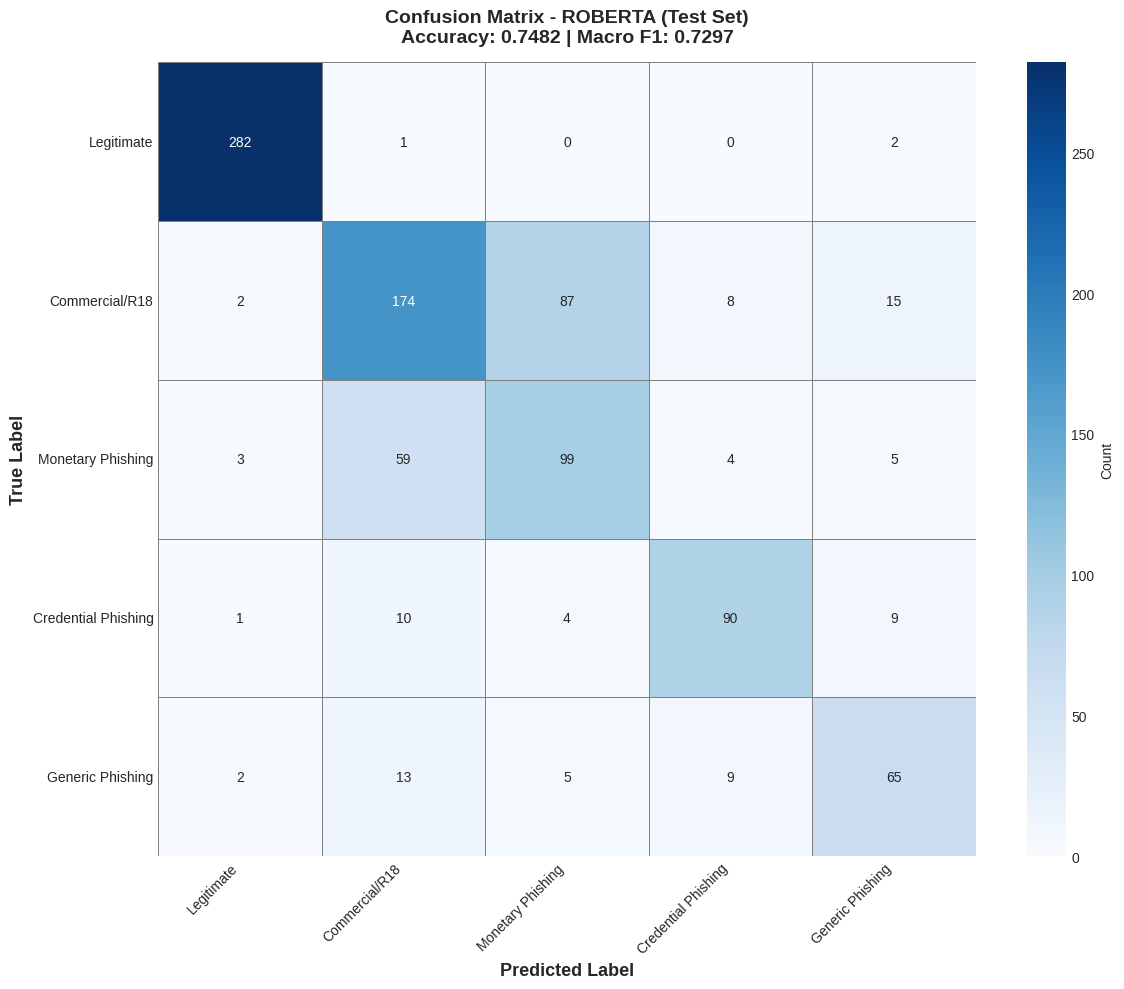


✓ Confusion matrix saved to: /content/drive/MyDrive/thesis_results/confusion_matrix_roberta.png


In [20]:
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_LABELS.values(),
    yticklabels=CLASS_LABELS.values(),
    cbar_kws={'label': 'Count'},
    linewidths=0.5,
    linecolor='gray'
)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - {best_model_name.upper()} (Test Set)\nAccuracy: {test_metrics["accuracy"]:.4f} | Macro F1: {test_metrics["macro_f1"]:.4f}',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save
cm_path = f'{RESULTS_DIR}/confusion_matrix_{best_model_name}.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix saved to: {cm_path}")

## 14. Classification Report

In [21]:
print('\n' + '=' * 80)
print('DETAILED CLASSIFICATION REPORT')
print('=' * 80)
print()
print(classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_LABELS.values(),
    digits=4
))
print('=' * 80)


DETAILED CLASSIFICATION REPORT

                     precision    recall  f1-score   support

         Legitimate     0.9724    0.9895    0.9809       285
     Commercial/R18     0.6770    0.6084    0.6409       286
  Monetary Phishing     0.5077    0.5824    0.5425       170
Credential Phishing     0.8108    0.7895    0.8000       114
   Generic Phishing     0.6771    0.6915    0.6842        94

           accuracy                         0.7482       949
          macro avg     0.7290    0.7322    0.7297       949
       weighted avg     0.7515    0.7482    0.7488       949



Generating comprehensive visualizations for 3 models...

Processing ROBERTA...


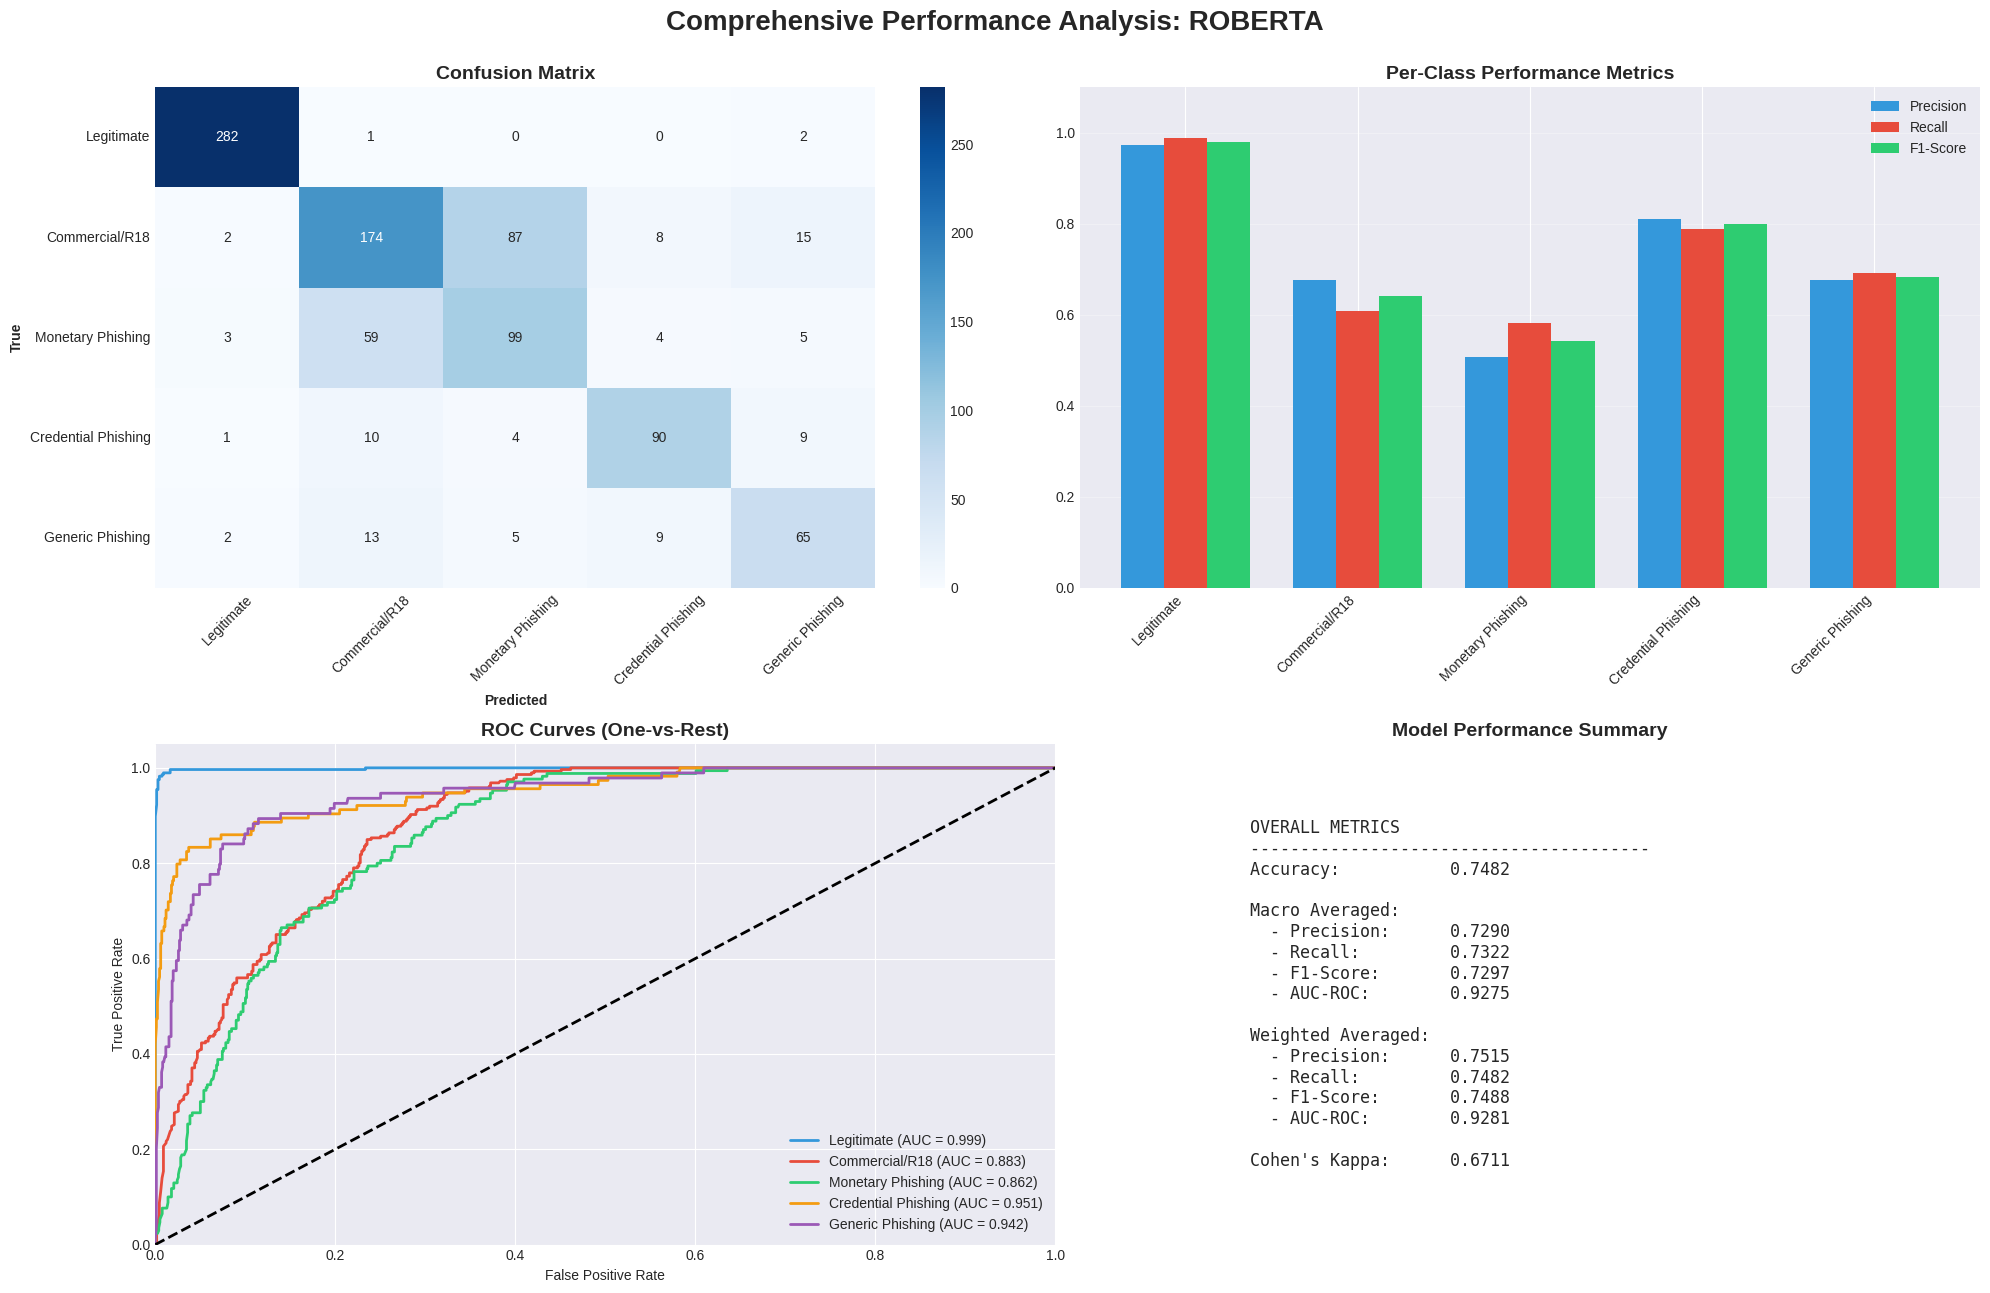

✓ Saved visualization to /content/drive/MyDrive/thesis_results/comprehensive_analysis_roberta.png

Processing DISTILBERT...


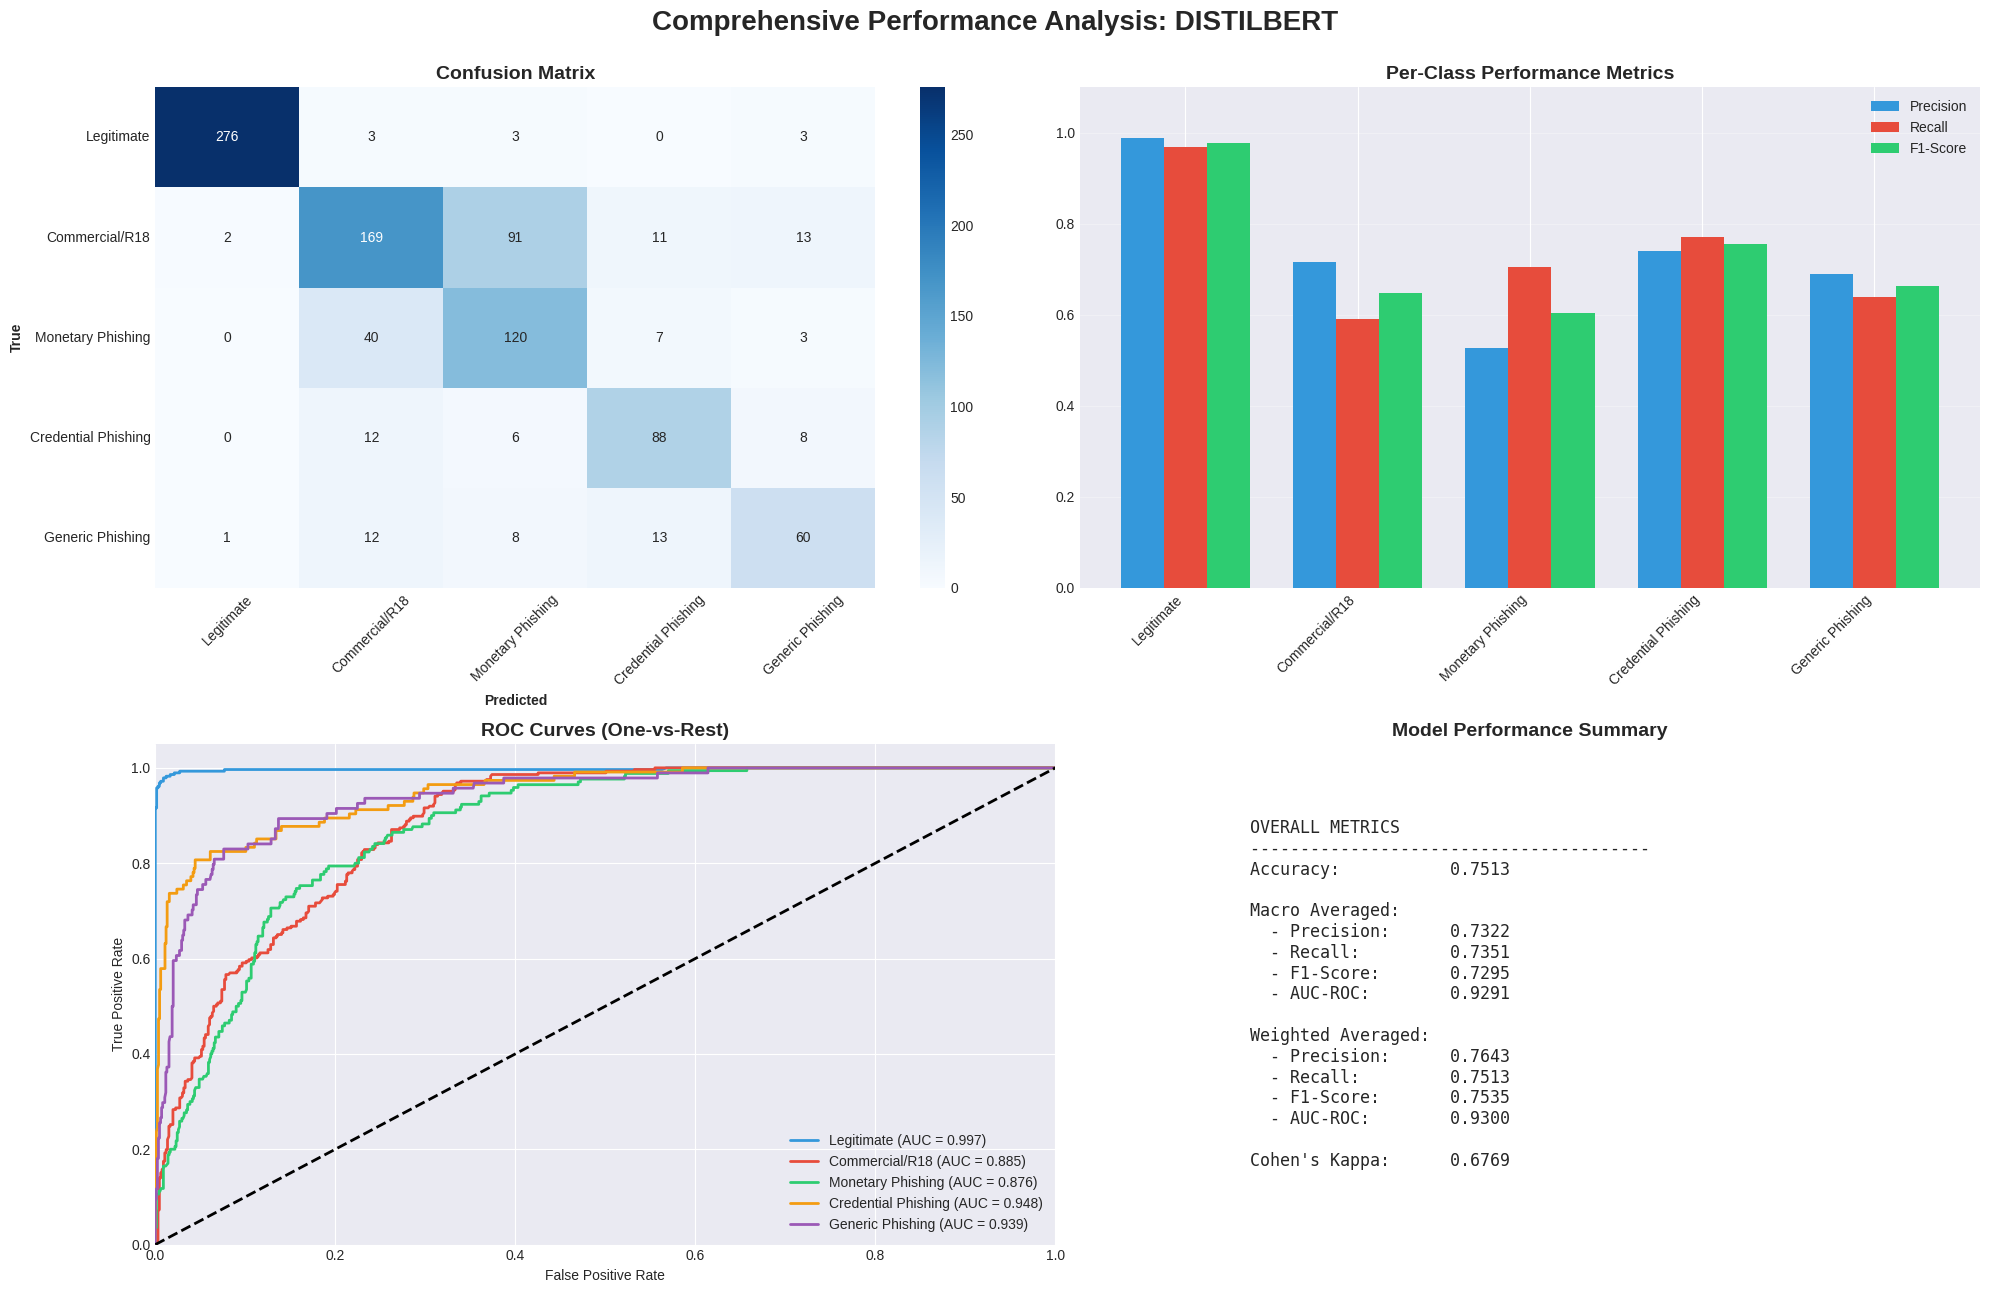

✓ Saved visualization to /content/drive/MyDrive/thesis_results/comprehensive_analysis_distilbert.png

Processing ALBERT...


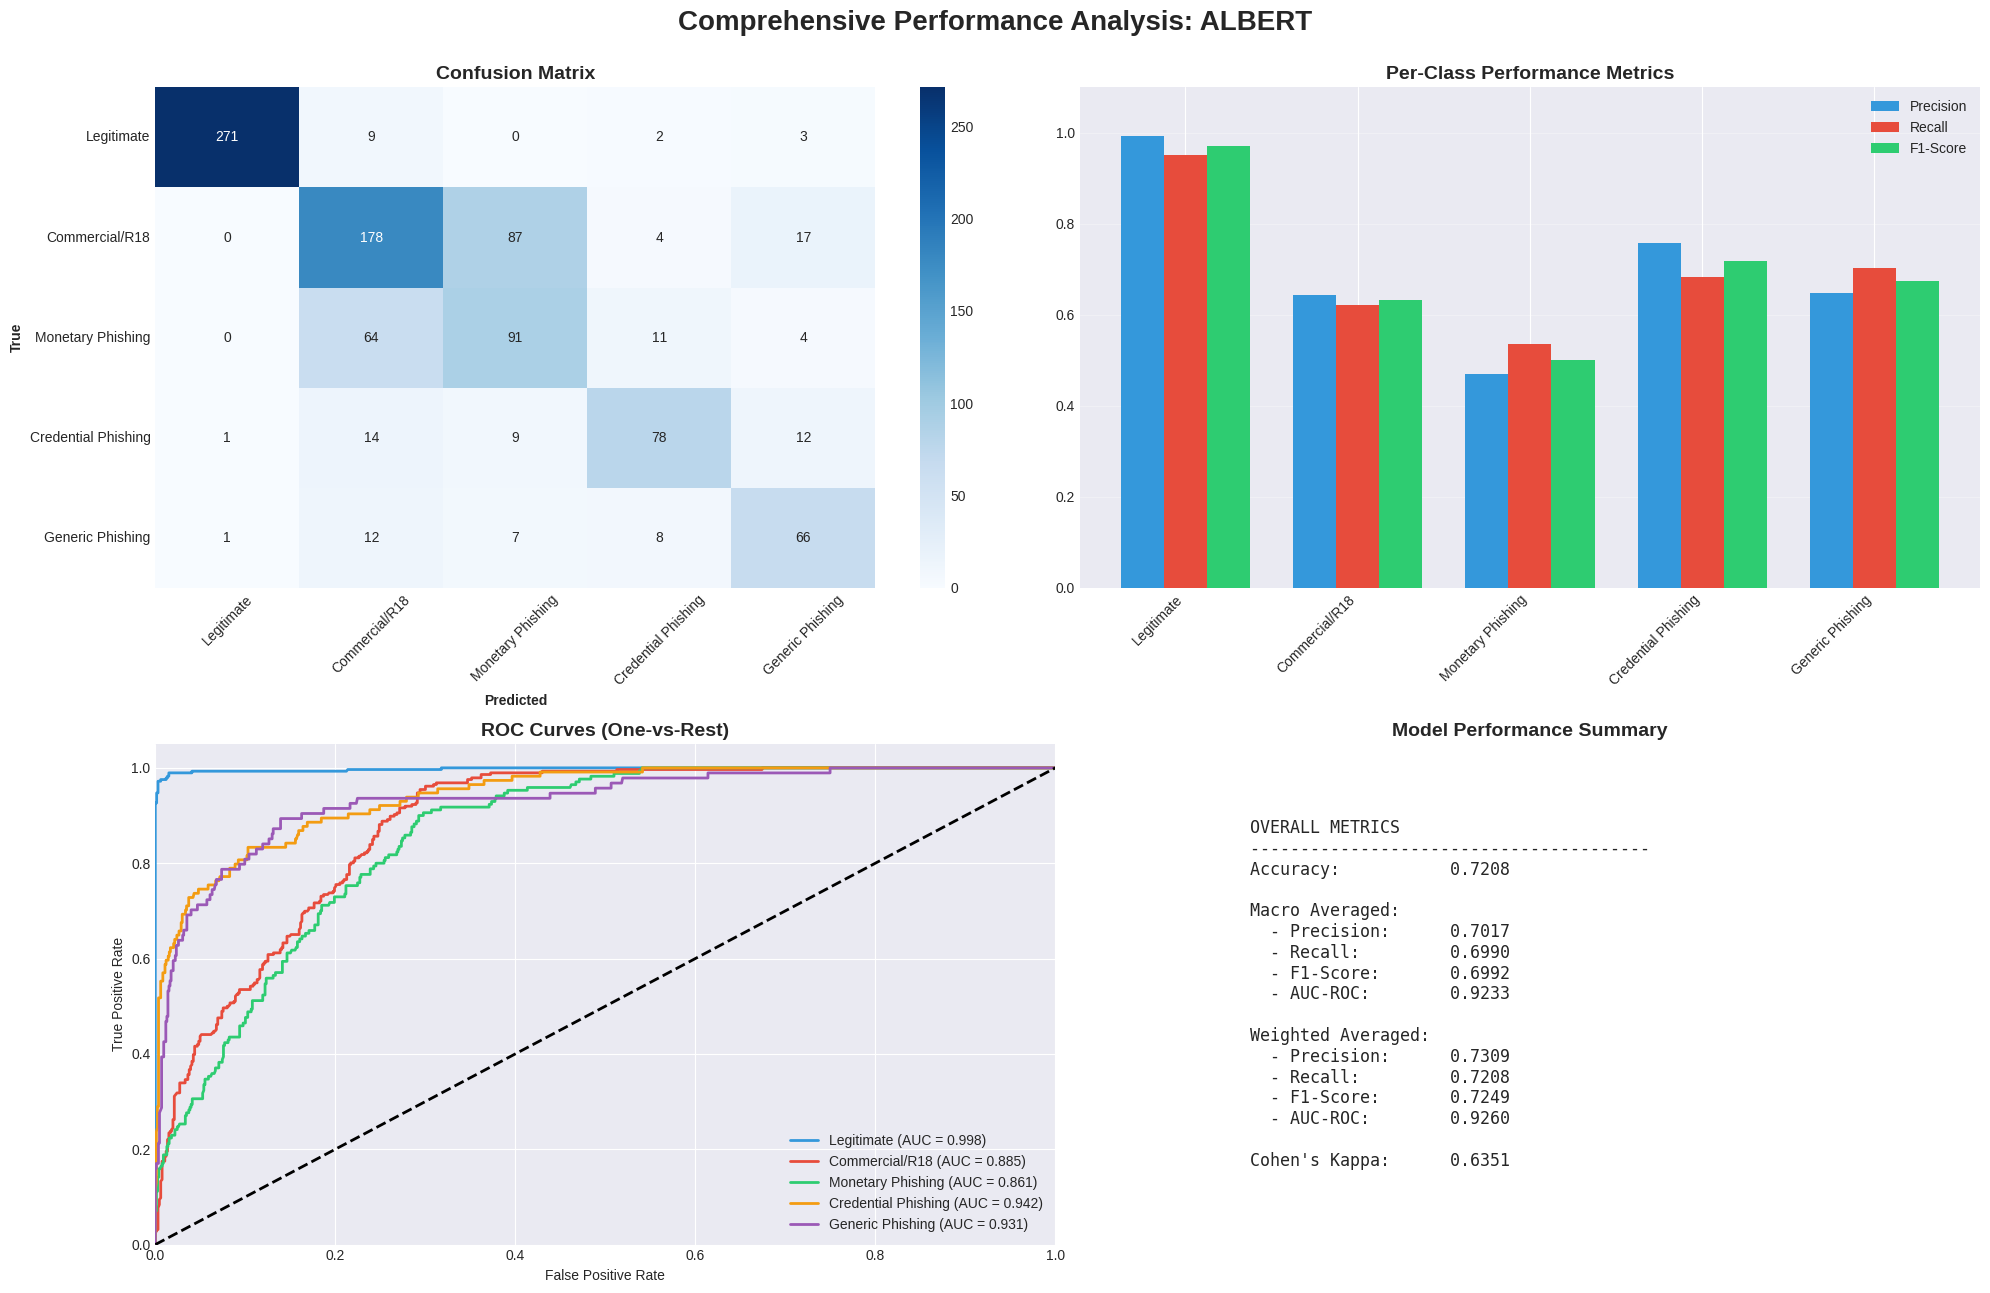

✓ Saved visualization to /content/drive/MyDrive/thesis_results/comprehensive_analysis_albert.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import numpy as np
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

# Ensure we have the necessary models loaded
if 'trained_models' not in locals() or not trained_models:
    print("No trained models found in memory. Please run the model loading cell first.")
else:
    print(f"Generating comprehensive visualizations for {len(trained_models)} models...")

    for model_name, model in trained_models.items():
        print(f"\nProcessing {model_name.upper()}...")

        # 1. Prepare Data
        model_id = CONFIG['models'][model_name]
        tokenizer = AutoTokenizer.from_pretrained(model_id)

        # Create temp loader for this model (specific tokenizer)
        temp_ds = PhishingDataset(X_test, y_test, tokenizer, CONFIG['max_length'])
        temp_collator = DataCollatorWithPadding(tokenizer=tokenizer)
        temp_loader = DataLoader(temp_ds, batch_size=CONFIG['batch_size'], collate_fn=temp_collator, num_workers=2)

        # 2. Evaluate
        preds, labels, probs = evaluate(model, temp_loader, device)
        metrics = compute_metrics(labels, preds, probs)

        # 3. Create Visualization (2x2 Grid)
        fig = plt.figure(figsize=(20, 14))
        plt.suptitle(f"Comprehensive Performance Analysis: {model_name.upper()}", fontsize=20, fontweight='bold', y=0.95)

        # Subplot 1: Confusion Matrix
        ax1 = fig.add_subplot(2, 2, 1)
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values(), ax=ax1)
        ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Predicted', fontweight='bold')
        ax1.set_ylabel('True', fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)

        # Subplot 2: Per-Class Metrics (Bar Chart)
        ax2 = fig.add_subplot(2, 2, 2)
        class_indices = range(len(CLASS_LABELS))
        class_names = [CLASS_LABELS[i] for i in class_indices]

        x = np.arange(len(class_names))
        width = 0.25

        ax2.bar(x - width, metrics['per_class_precision'], width, label='Precision', color='#3498db')
        ax2.bar(x, metrics['per_class_recall'], width, label='Recall', color='#e74c3c')
        ax2.bar(x + width, metrics['per_class_f1'], width, label='F1-Score', color='#2ecc71')

        ax2.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(class_names, rotation=45, ha='right')
        ax2.set_ylim(0, 1.1)
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)

        # Subplot 3: ROC Curves
        ax3 = fig.add_subplot(2, 2, 3)
        y_test_bin = label_binarize(labels, classes=list(class_indices))
        n_classes = y_test_bin.shape[1]
        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
            roc_auc = auc(fpr, tpr)
            ax3.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                     label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

        ax3.plot([0, 1], [0, 1], 'k--', lw=2)
        ax3.set_xlim([0.0, 1.0])
        ax3.set_ylim([0.0, 1.05])
        ax3.set_xlabel('False Positive Rate')
        ax3.set_ylabel('True Positive Rate')
        ax3.set_title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
        ax3.legend(loc="lower right")

        # Subplot 4: Summary Metrics Text
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.axis('off')

        summary_text = f"""
        OVERALL METRICS
        ----------------------------------------
        Accuracy:           {metrics['accuracy']:.4f}

        Macro Averaged:
          - Precision:      {metrics['macro_precision']:.4f}
          - Recall:         {metrics['macro_recall']:.4f}
          - F1-Score:       {metrics['macro_f1']:.4f}
          - AUC-ROC:        {metrics['auc_macro']:.4f}

        Weighted Averaged:
          - Precision:      {metrics['weighted_precision']:.4f}
          - Recall:         {metrics['weighted_recall']:.4f}
          - F1-Score:       {metrics['weighted_f1']:.4f}
          - AUC-ROC:        {metrics['auc_weighted']:.4f}

        Cohen's Kappa:      {metrics['cohen_kappa']:.4f}
        """

        ax4.text(0.1, 0.5, summary_text, fontsize=12, family='monospace', va='center')
        ax4.set_title('Model Performance Summary', fontsize=14, fontweight='bold')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        save_path = f"{RESULTS_DIR}/comprehensive_analysis_{model_name}.png"
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"✓ Saved visualization to {save_path}")

## 15. Error Analysis

Examine misclassified examples to understand model limitations and inform future improvements.

In [23]:
print('\n' + '=' * 80)
print('ERROR ANALYSIS')
print('=' * 80)

# Find misclassified samples
errors = []
for i, (pred, true) in enumerate(zip(test_preds, test_labels)):
    if pred != true:
        errors.append({
            'index': i,
            'text': X_test[i],
            'true_label': CLASS_LABELS[true],
            'predicted_label': CLASS_LABELS[pred],
            'true_class': true,
            'pred_class': pred,
            'confidence': test_probs[i][pred],
            'true_prob': test_probs[i][true]
        })

print(f"\nMisclassifications: {len(errors)}/{len(test_labels)} ({len(errors)/len(test_labels)*100:.2f}%)")
print(f"Correct: {len(test_labels)-len(errors)}/{len(test_labels)} ({(len(test_labels)-len(errors))/len(test_labels)*100:.2f}%)")

# Error breakdown by true class
print(f"\n{'='*80}")
print('ERRORS BY TRUE CLASS')
print(f"{'='*80}")
print(f"{'True Class':<30} {'Errors':>10} {'Total':>10} {'Error Rate':>12}")
print('-' * 80)
for label in sorted(CLASS_LABELS.keys()):
    class_errors = [e for e in errors if e['true_class'] == label]
    class_total = (test_labels == label).sum()
    if class_total > 0:
        error_rate = len(class_errors) / class_total * 100
        print(f"{CLASS_LABELS[label]:<30} {len(class_errors):>10} {class_total:>10} {error_rate:>11.1f}%")
print('=' * 80)

# Most common confusion pairs
confusion_pairs = defaultdict(int)
for error in errors:
    pair = (error['true_label'], error['predicted_label'])
    confusion_pairs[pair] += 1

print(f"\n{'='*80}")
print('MOST COMMON CONFUSION PAIRS (Top 10)')
print(f"{'='*80}")
print(f"{'True Label':<25} {'→':>3} {'Predicted Label':<25} {'Count':>10}")
print('-' * 80)
for (true_label, pred_label), count in sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{true_label:<25} {'→':>3} {pred_label:<25} {count:>10}")
print('=' * 80)

# Show sample errors
print(f"\n{'='*80}")
print('SAMPLE MISCLASSIFIED EMAILS (First 10)')
print(f"{'='*80}")

for i, error in enumerate(errors[:10], 1):
    print(f"\nError #{i}:")
    print(f"  True Label:      {error['true_label']}")
    print(f"  Predicted Label: {error['predicted_label']}")
    print(f"  Confidence:      {error['confidence']:.3f} (pred) | {error['true_prob']:.3f} (true)")
    print(f"  Text (first 250 chars):")
    print(f"    {error['text'][:250]}...")
    print('-' * 80)

# Save full error analysis to CSV
error_df = pd.DataFrame(errors)
error_path = f"{RESULTS_DIR}/misclassified_samples.csv"
error_df.to_csv(error_path, index=False)
print(f"\n✓ Full error analysis saved to: {error_path}")
print(f"  ({len(errors)} misclassified samples with text, labels, and probabilities)")


ERROR ANALYSIS

Misclassifications: 239/949 (25.18%)
Correct: 710/949 (74.82%)

ERRORS BY TRUE CLASS
True Class                         Errors      Total   Error Rate
--------------------------------------------------------------------------------
Legitimate                              3        285         1.1%
Commercial/R18                        112        286        39.2%
Monetary Phishing                      71        170        41.8%
Credential Phishing                    24        114        21.1%
Generic Phishing                       29         94        30.9%

MOST COMMON CONFUSION PAIRS (Top 10)
True Label                  → Predicted Label                Count
--------------------------------------------------------------------------------
Commercial/R18              → Monetary Phishing                 87
Monetary Phishing           → Commercial/R18                    59
Commercial/R18              → Generic Phishing                  15
Generic Phishing            → Comm

## 16. Save Final Results and Summary

Package all results for thesis writing and analysis.

In [24]:
# Prepare serializable CV results (handle case where CV loop was skipped)
cv_results_serializable = {
    k: {
        'mean_f1': float(v['mean_f1']),
        'std_f1': float(v['std_f1']),
        'fold_scores': [float(x) for x in v['fold_scores']],
        'training_time': float(v['training_time'])
    }
    for k, v in cv_results.items()
}

# Create a JSON-safe version of CONFIG (convert numpy int64 keys to standard int)
config_safe = CONFIG.copy()
if 'balance_targets' in config_safe:
    config_safe['balance_targets'] = {int(k): int(v) for k, v in config_safe['balance_targets'].items()}
if 'balancing_ratios' in config_safe:
    config_safe['balancing_ratios'] = {int(k): float(v) for k, v in config_safe['balancing_ratios'].items()}

# --- COMPUTE METRICS FOR ALL MODELS ---
all_models_metrics = {}

print("Computing detailed metrics for all trained models for final_results.json...")
if 'trained_models' in locals() and trained_models:
    for name, model in trained_models.items():
        print(f"  Processing {name}...")
        try:
            # Get model-specific tokenizer and create loader
            model_id = CONFIG['models'][name]
            tokenizer = AutoTokenizer.from_pretrained(model_id)

            # Create temporary test loader
            temp_ds = PhishingDataset(X_test, y_test, tokenizer, CONFIG['max_length'])
            temp_col = DataCollatorWithPadding(tokenizer=tokenizer)
            temp_loader = DataLoader(temp_ds, batch_size=CONFIG['batch_size'], collate_fn=temp_col, num_workers=2)

            # Evaluate
            m_preds, m_labels, m_probs = evaluate(model, temp_loader, device)
            m_metrics = compute_metrics(m_labels, m_preds, m_probs)

            # Format per-class metrics
            per_class_dict = {
                CLASS_LABELS[i]: {
                    'precision': float(m_metrics['per_class_precision'][i]),
                    'recall': float(m_metrics['per_class_recall'][i]),
                    'f1_score': float(m_metrics['per_class_f1'][i]),
                    'support': int((m_labels == i).sum())
                }
                for i in range(len(CLASS_LABELS))
            }

            # Remove array metrics from main dict to avoid JSON errors
            overall_clean = {k: float(v) for k, v in m_metrics.items() if not k.startswith('per_class')}

            all_models_metrics[name] = {
                'overall_metrics': overall_clean,
                'per_class_metrics': per_class_dict
            }
        except Exception as e:
            print(f"  Error processing {name}: {e}")
else:
    print("  Warning: 'trained_models' dict not found or empty. Only saving best model results.")

# Compile comprehensive results
final_results = {
    'timestamp': datetime.now().isoformat(),
    'config': config_safe,

    'dataset_info': {
        'total_samples': len(full_df),
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'class_distribution': {
            CLASS_LABELS[i]: int((full_df['label'] == i).sum())
            for i in sorted(CLASS_LABELS.keys())
        },
        'balancing_strategy': {
            'method': CONFIG.get('balancing_method', 'hybrid'),
            'description': 'Dynamic balancing strategy (refer to config)',
            'targets': config_safe.get('balance_targets', {})
        }
    },

    'cross_validation': {
        'n_folds': CONFIG['n_folds'],
        'results': cv_results_serializable
    },

    'best_model': {
        'name': best_model_name,
        'model_id': best_model_id,
        'cv_mean_f1': float(cv_results[best_model_name]['mean_f1']),
        'cv_std_f1': float(cv_results[best_model_name]['std_f1'])
    },

    # Extended section: Performance of ALL models
    'all_models_performance': all_models_metrics,

    'test_metrics': {
        k: float(v) if not k.startswith('per_class') else v.tolist()
        for k, v in test_metrics.items()
    },

    'per_class_results': {
        CLASS_LABELS[i]: {
            'precision': float(test_metrics['per_class_precision'][i]),
            'recall': float(test_metrics['per_class_recall'][i]),
            'f1_score': float(test_metrics['per_class_f1'][i]),
            'support': int((test_labels == i).sum())
        }
        for i in range(len(CLASS_LABELS))
    },

    'error_analysis': {
        'total_errors': len(errors),
        'error_rate': len(errors) / len(test_labels),
        'errors_by_class': {
            CLASS_LABELS[label]: len([e for e in errors if e['true_class'] == label])
            for label in CLASS_LABELS.keys()
        },
        'top_confusion_pairs': [
            {'true': true_label, 'predicted': pred_label, 'count': count}
            for (true_label, pred_label), count in sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]
        ]
    }
}

# Save to JSON
results_path = f"{RESULTS_DIR}/final_results.json"
with open(results_path, 'w') as f:
    json.dump(final_results, f, indent=2)

# Print summary
print('\n' + '=' * 80)
print('TRAINING COMPLETE - ALL RESULTS SAVED')
print('=' * 80)
print(f"\n📁 Results saved to Google Drive: {RESULTS_DIR}/")
print(f"\n  ✓ final_results.json - Comprehensive metrics (all models) and configuration")
print(f"  ✓ cv_results.json - Cross-validation fold scores")
print(f"  ✓ confusion_matrix_{best_model_name}.png - Confusion matrix visualization")
print(f"  ✓ misclassified_samples.csv - Error analysis with examples")
print(f"\n📁 Models saved to: {CHECKPOINT_DIR}/")
print(f"\n  ✓ {best_model_name}_best.pt - Best final model checkpoint")
print(f"  ✓ {best_model_name}_fold*_best.pt - CV fold checkpoints (5 files)")

# --- MODIFIED SECTION: PRINT PER-CLASS STATISTICS FOR ALL MODELS ---
print(f"\n{'='*80}")
print('TEST SET PERFORMANCE - ALL MODELS')
print(f"{'='*80}")

for model_name in sorted(all_models_metrics.keys()):
    metrics = all_models_metrics[model_name]
    overall = metrics['overall_metrics']
    per_class = metrics['per_class_metrics']

    print(f"\n{'─'*80}")
    print(f"Model: {model_name.upper()}")
    print(f"{'─'*80}")

    print(f"\nOverall Metrics:")
    print(f"  Accuracy:      {overall['accuracy']:.4f}")
    print(f"  Macro F1:      {overall['macro_f1']:.4f}")
    print(f"  Weighted F1:   {overall['weighted_f1']:.4f}")
    print(f"  Cohen's Kappa: {overall['cohen_kappa']:.4f}")
    print(f"  AUC-ROC:       {overall['auc_macro']:.4f}")

    print(f"\nPer-Class Performance:")
    print(f"  {'Class':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

    for class_name in [CLASS_LABELS[i] for i in sorted(CLASS_LABELS.keys())]:
        class_metrics = per_class[class_name]
        print(f"  {class_name:<25} {class_metrics['precision']:>10.4f} {class_metrics['recall']:>10.4f} "
              f"{class_metrics['f1_score']:>10.4f} {class_metrics['support']:>10}")

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name.upper()}")
print(f"{'='*80}")

print(f"\n🎉 Training pipeline complete!")
print('\nNext steps for thesis:')
print('  1. Analyze confusion matrix for class-specific patterns')
print('  2. Review error analysis CSV for failure modes')
print('  3. Compare model performance across all architectures')
print('  4. Prepare tables and figures from saved results')
print('=' * 80)

Computing detailed metrics for all trained models for final_results.json...
  Processing roberta...
  Processing distilbert...
  Processing albert...

TRAINING COMPLETE - ALL RESULTS SAVED

📁 Results saved to Google Drive: /content/drive/MyDrive/thesis_results/

  ✓ final_results.json - Comprehensive metrics (all models) and configuration
  ✓ cv_results.json - Cross-validation fold scores
  ✓ confusion_matrix_roberta.png - Confusion matrix visualization
  ✓ misclassified_samples.csv - Error analysis with examples

📁 Models saved to: /content/drive/MyDrive/thesis_checkpoints/

  ✓ roberta_best.pt - Best final model checkpoint
  ✓ roberta_fold*_best.pt - CV fold checkpoints (5 files)

TEST SET PERFORMANCE - ALL MODELS

────────────────────────────────────────────────────────────────────────────────
Model: ALBERT
────────────────────────────────────────────────────────────────────────────────

Overall Metrics:
  Accuracy:      0.7208
  Macro F1:      0.6992
  Weighted F1:   0.7249
  Cohen

## 17. Comprehensive Visualizations and Model Analysis

This section provides publication-ready visualizations and numerical tables for thesis documentation.

### Overview:
- **17.1**: Model Comparison (CV performance across all models)
- **17.2**: Training Dynamics (learning curves for best model)
- **17.3**: Per-Class Analysis (which phishing types are hardest?)
- **17.4**: ROC and Precision-Recall Curves (threshold analysis)
- **17.5**: Data Distribution Analysis (balancing impact)

All visualizations are saved to Google Drive for inclusion in thesis.

### 17.1 Model Comparison

Compare all three models (ALBERT, DistilBERT, RoBERTa) on cross-validation performance.


17.1 MODEL COMPARISON


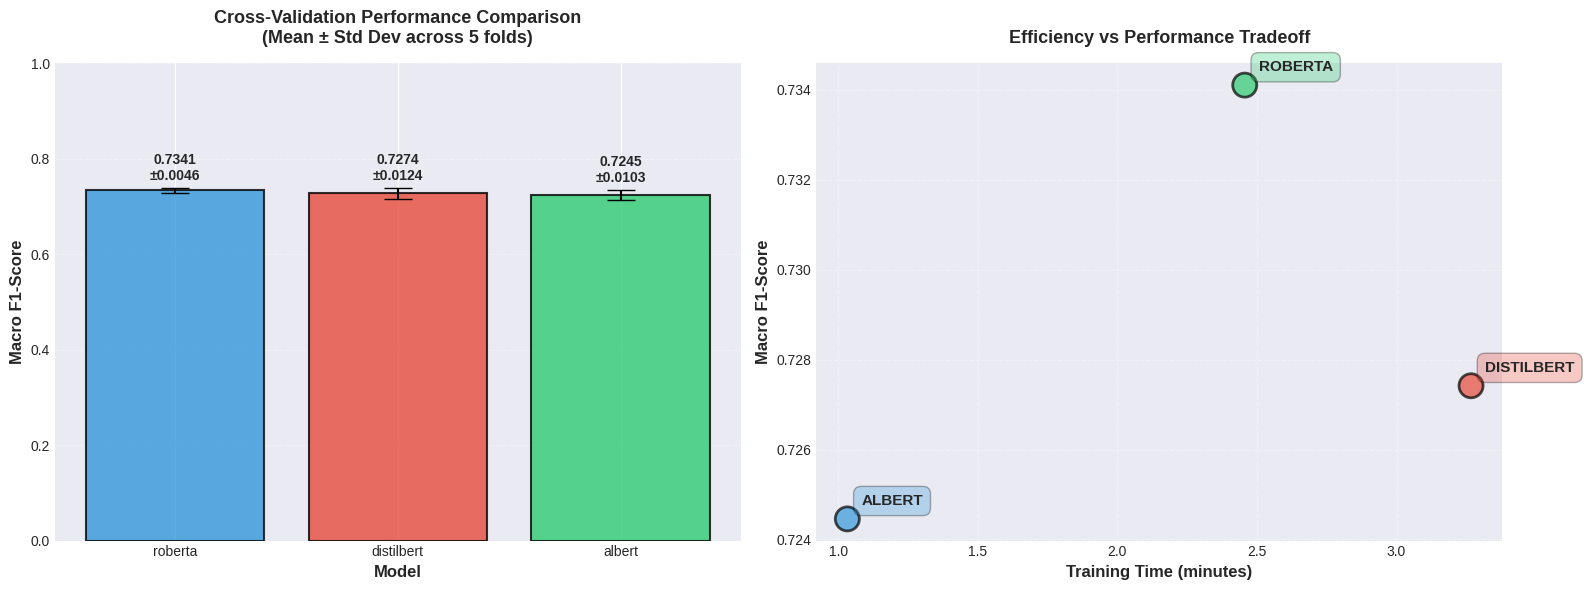


✓ Figure saved: /content/drive/MyDrive/thesis_results/model_comparison_cv.png

TABLE 1: Cross-Validation Results Summary

Model                Mean F1      Std Dev   Time (min)    Best Fold   Worst Fold
--------------------------------------------------------------------------------
roberta               0.7341       0.0046          2.5       0.7422       0.7300
distilbert            0.7274       0.0124          3.3       0.7474       0.7110
albert                0.7245       0.0103          1.0       0.7390       0.7068

TABLE 2: Individual Fold Scores

Model               Fold 1     Fold 2     Fold 3     Fold 4     Fold 5
--------------------------------------------------------------------------------
albert              0.7068     0.7250     0.7390     0.7243     0.7272 
distilbert          0.7268     0.7192     0.7474     0.7110     0.7326 
roberta             0.7319     0.7300     0.7422     0.7301     0.7363 


In [25]:
print('\n' + '=' * 80)
print('17.1 MODEL COMPARISON')
print('=' * 80)

# Prepare data for plotting
model_names = list(cv_results.keys())
mean_f1s = [cv_results[m]['mean_f1'] for m in model_names]
std_f1s = [cv_results[m]['std_f1'] for m in model_names]
training_times = [cv_results[m]['training_time']/60 for m in model_names]  # Convert to minutes

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: CV Performance Comparison with error bars
ax1 = axes[0]
bars = ax1.bar(model_names, mean_f1s, yerr=std_f1s, capsize=10,
               color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_title('Cross-Validation Performance Comparison\n(Mean ± Std Dev across 5 folds)',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, mean_f1s, std_f1s)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
             f'{mean:.4f}\n±{std:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Training Time vs Performance
ax2 = axes[1]
colors_map = {'albert': '#3498db', 'distilbert': '#e74c3c', 'roberta': '#2ecc71'}
colors = [colors_map.get(m, '#95a5a6') for m in model_names]

scatter = ax2.scatter(training_times, mean_f1s, s=300, c=colors, alpha=0.7,
                     edgecolors='black', linewidth=2)
ax2.set_xlabel('Training Time (minutes)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('Efficiency vs Performance Tradeoff', fontsize=13, fontweight='bold', pad=15)
ax2.grid(alpha=0.3, linestyle='--')

# Add model labels
# FIX: Renamed 'time' to 't_time' to avoid shadowing the time module
for i, (name, t_time, f1) in enumerate(zip(model_names, training_times, mean_f1s)):
    ax2.annotate(name.upper(), (t_time, f1),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison_cv.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: {RESULTS_DIR}/model_comparison_cv.png")

# Numerical Table: Complete CV Results
print('\n' + '=' * 80)
print('TABLE 1: Cross-Validation Results Summary')
print('=' * 80)
print(f"\n{'Model':<15} {'Mean F1':>12} {'Std Dev':>12} {'Time (min)':>12} {'Best Fold':>12} {'Worst Fold':>12}")
print('-' * 80)
for model_name in sorted(cv_results.keys(), key=lambda x: cv_results[x]['mean_f1'], reverse=True):
    result = cv_results[model_name]
    best_fold = max(result['fold_scores'])
    worst_fold = min(result['fold_scores'])
    print(f"{model_name:<15} {result['mean_f1']:>12.4f} {result['std_f1']:>12.4f} "
          f"{result['training_time']/60:>12.1f} {best_fold:>12.4f} {worst_fold:>12.4f}")
print('=' * 80)

# Individual fold scores table
print('\n' + '=' * 80)
print('TABLE 2: Individual Fold Scores')
print('=' * 80)
print(f"\n{'Model':<15} {'Fold 1':>10} {'Fold 2':>10} {'Fold 3':>10} {'Fold 4':>10} {'Fold 5':>10}")
print('-' * 80)
for model_name in sorted(cv_results.keys()):
    scores = cv_results[model_name]['fold_scores']
    print(f"{model_name:<15} ", end='')
    for score in scores:
        print(f"{score:>10.4f} ", end='')
    print()
print('=' * 80)

### 17.2 Training Dynamics (Best Model)

Analyze how the best model learned over epochs: loss curves, accuracy progression, and early stopping behavior.


17.2 TRAINING DYNAMICS (BEST MODEL)


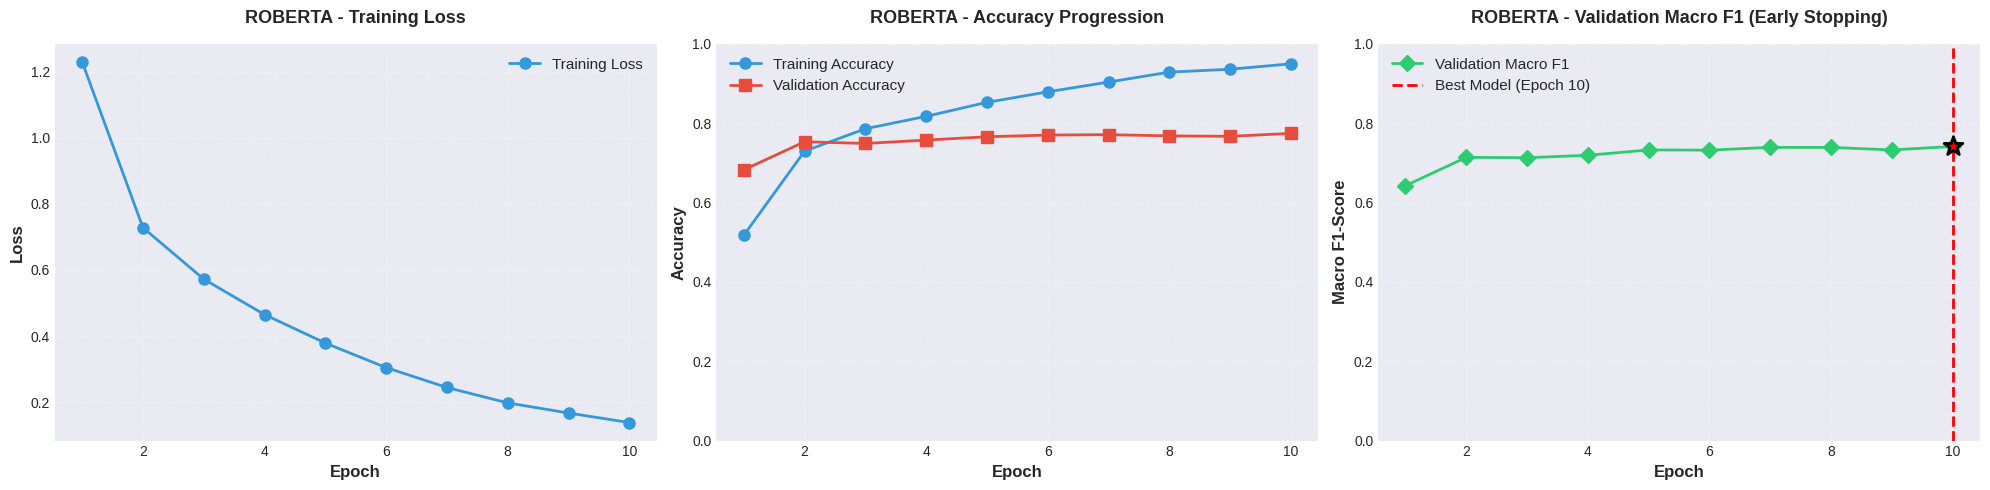


✓ Figure saved: /content/drive/MyDrive/thesis_results/training_dynamics_roberta.png

TABLE 3: Epoch-by-Epoch Training Metrics (ROBERTA)

  Epoch   Train Loss    Train Acc      Val Acc   Val Macro F1                Notes
--------------------------------------------------------------------------------
      1       1.2294       0.5176       0.6825         0.6426                     
      2       0.7279       0.7295       0.7532         0.7139                     
      3       0.5722       0.7859       0.7489         0.7130                     
      4       0.4650       0.8173       0.7574         0.7191                     
      5       0.3788       0.8525       0.7658         0.7326                     
      6       0.3047       0.8790       0.7700         0.7320                     
      7       0.2445       0.9037       0.7711         0.7391                     
      8       0.1978       0.9287       0.7679         0.7389                     
      9       0.1673       0.9359 

In [26]:
print('\n' + '=' * 80)
print('17.2 TRAINING DYNAMICS (BEST MODEL)')
print('=' * 80)

# Extract training history from checkpoint
checkpoint_path = f"{CHECKPOINT_DIR}/{best_model_name}_best.pt"
# FIX: Set weights_only=False to allow loading history dict
checkpoint = torch.load(checkpoint_path, weights_only=False)
history = checkpoint['history']

epochs_trained = len(history['train_loss'])
epochs_range = range(1, epochs_trained + 1)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Loss Curves
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], 'o-', linewidth=2,
         markersize=8, label='Training Loss', color='#3498db')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title(f'{best_model_name.upper()} - Training Loss',
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)

# Plot 2: Accuracy Curves
ax2 = axes[1]
ax2.plot(epochs_range, history['train_acc'], 'o-', linewidth=2,
         markersize=8, label='Training Accuracy', color='#3498db')
ax2.plot(epochs_range, history['val_acc'], 's-', linewidth=2,
         markersize=8, label='Validation Accuracy', color='#e74c3c')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title(f'{best_model_name.upper()} - Accuracy Progression',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim([0, 1.0])
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

# Plot 3: Validation Macro F1 with Early Stopping
ax3 = axes[2]
ax3.plot(epochs_range, history['val_macro_f1'], 'D-', linewidth=2,
         markersize=8, label='Validation Macro F1', color='#2ecc71')

# Mark best epoch
best_epoch = checkpoint['epoch'] + 1
best_f1_val = checkpoint['best_f1']
ax3.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2,
            label=f'Best Model (Epoch {best_epoch})')
ax3.scatter([best_epoch], [best_f1_val], s=200, c='red', marker='*',
            edgecolors='black', linewidth=2, zorder=5)

ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax3.set_title(f'{best_model_name.upper()} - Validation Macro F1 (Early Stopping)',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_ylim([0, 1.0])
ax3.grid(alpha=0.3, linestyle='--')
ax3.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_dynamics_{best_model_name}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: {RESULTS_DIR}/training_dynamics_{best_model_name}.png")

# Numerical Table: Epoch-by-Epoch Metrics
print('\n' + '=' * 80)
print(f'TABLE 3: Epoch-by-Epoch Training Metrics ({best_model_name.upper()})')
print('=' * 80)
print(f"\n{'Epoch':>7} {'Train Loss':>12} {'Train Acc':>12} {'Val Acc':>12} {'Val Macro F1':>14} {'Notes':>20}")
print('-' * 80)
for epoch in range(epochs_trained):
    notes = ''
    if epoch == checkpoint['epoch']:
        notes = '← BEST MODEL'
    print(f"{epoch+1:>7} {history['train_loss'][epoch]:>12.4f} "
          f"{history['train_acc'][epoch]:>12.4f} {history['val_acc'][epoch]:>12.4f} "
          f"{history['val_macro_f1'][epoch]:>14.4f} {notes:>20}")
print('=' * 80)

# Early stopping analysis
print('\n' + '=' * 80)
print('Early Stopping Analysis')
print('=' * 80)
print(f"Best epoch: {best_epoch}/{CONFIG['epochs']}")
print(f"Best validation Macro F1: {best_f1_val:.4f}")
print(f"Total epochs trained: {epochs_trained}")
if epochs_trained < CONFIG['epochs']:
    print(f"Early stopping triggered: YES (saved {CONFIG['epochs'] - epochs_trained} epoch(s))")
else:
    print(f"Early stopping triggered: NO (trained full {CONFIG['epochs']} epochs)")
print('=' * 80)

### 17.3 Per-Class Analysis

Examine which phishing types are easiest/hardest to detect. This guides future research directions.


17.3 PER-CLASS ANALYSIS


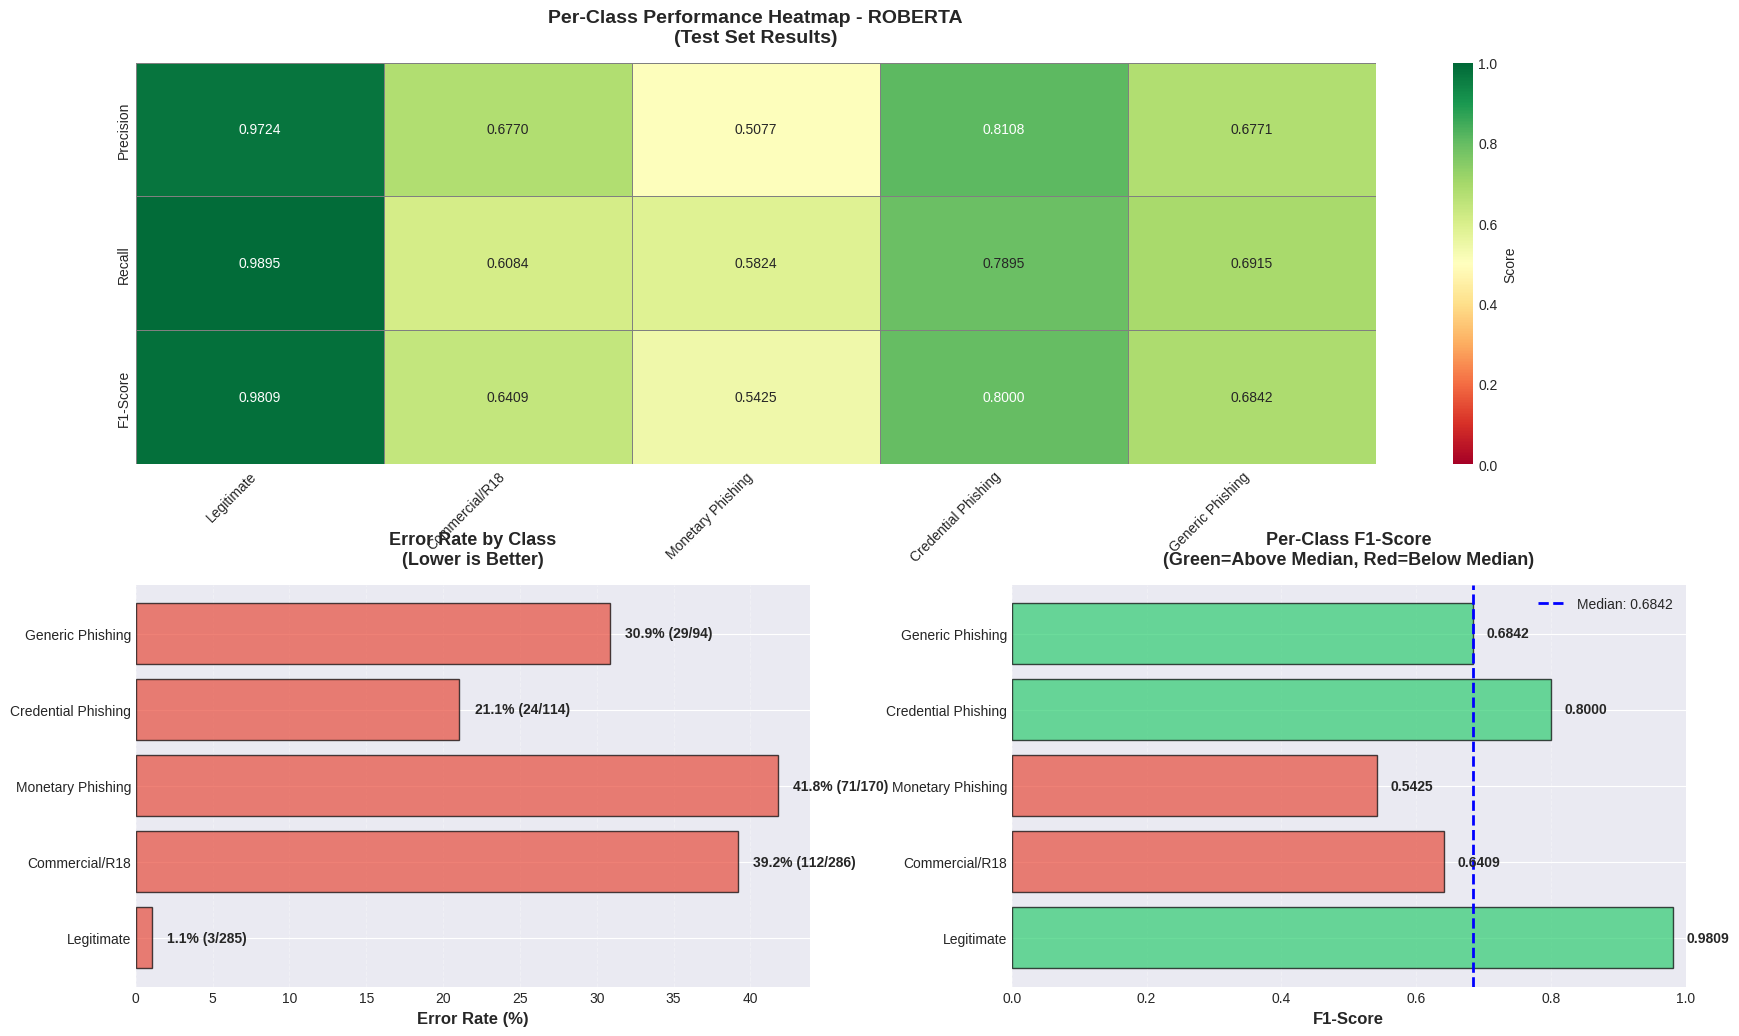


✓ Figure saved: /content/drive/MyDrive/thesis_results/per_class_analysis.png

TABLE 4: Detailed Per-Class Performance

  Class Label                       Precision      Recall    F1-Score   Support    Errors
----------------------------------------------------------------------------------------------------
      0 Legitimate                     0.9724      0.9895      0.9809       285         3
      1 Commercial/R18                 0.6770      0.6084      0.6409       286       112
      2 Monetary Phishing              0.5077      0.5824      0.5425       170        71
      3 Credential Phishing            0.8108      0.7895      0.8000       114        24
      4 Generic Phishing               0.6771      0.6915      0.6842        94        29
----------------------------------------------------------------------------------------------------
AVG     Macro Average                  0.7290      0.7322      0.7297       949       239

CLASS DIFFICULTY RANKING (by F1-Score)

  Rank 

In [27]:
print('\n' + '=' * 80)
print('17.3 PER-CLASS ANALYSIS')
print('=' * 80)

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Plot 1: Per-Class Performance Heatmap
ax1 = fig.add_subplot(gs[0, :])

# Prepare data for heatmap
class_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
metrics_data = np.array([
    test_metrics['per_class_precision'],
    test_metrics['per_class_recall'],
    test_metrics['per_class_f1']
])

# Create heatmap
sns.heatmap(metrics_data, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=['Precision', 'Recall', 'F1-Score'],
            cbar_kws={'label': 'Score'}, linewidths=0.5, linecolor='gray', ax=ax1)
ax1.set_title(f'Per-Class Performance Heatmap - {best_model_name.upper()}\n(Test Set Results)',
              fontsize=14, fontweight='bold', pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Plot 2: Error Rate by Class
ax2 = fig.add_subplot(gs[1, 0])

class_totals = [(test_labels == i).sum() for i in range(len(CLASS_LABELS))]
class_errors = [len([e for e in errors if e['true_class'] == i]) for i in range(len(CLASS_LABELS))]
error_rates = [err/total*100 if total > 0 else 0 for err, total in zip(class_errors, class_totals)]

bars = ax2.barh(class_names, error_rates, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Error Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Error Rate by Class\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, rate, err, tot) in enumerate(zip(bars, error_rates, class_errors, class_totals)):
    width = bar.get_width()
    ax2.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}% ({err}/{tot})',
             va='center', fontsize=10, fontweight='bold')

# Plot 3: F1-Score Comparison (Best vs Worst Classes)
ax3 = fig.add_subplot(gs[1, 1])

f1_scores = test_metrics['per_class_f1']
colors_f1 = ['#2ecc71' if f1 >= np.median(f1_scores) else '#e74c3c' for f1 in f1_scores]

bars = ax3.barh(class_names, f1_scores, color=colors_f1, alpha=0.7, edgecolor='black')
ax3.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax3.set_title('Per-Class F1-Score\n(Green=Above Median, Red=Below Median)',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xlim([0, 1.0])
ax3.grid(axis='x', alpha=0.3, linestyle='--')

# Add median line
median_f1 = np.median(f1_scores)
ax3.axvline(x=median_f1, color='blue', linestyle='--', linewidth=2,
            label=f'Median: {median_f1:.4f}')
ax3.legend(fontsize=10)

# Add value labels
for bar, f1 in zip(bars, f1_scores):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{f1:.4f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: {RESULTS_DIR}/per_class_analysis.png")

# Numerical Table: Detailed Per-Class Metrics
print('\n' + '=' * 80)
print('TABLE 4: Detailed Per-Class Performance')
print('=' * 80)
print(f"\n{'Class':>7} {'Label':<25} {'Precision':>11} {'Recall':>11} {'F1-Score':>11} "
      f"{'Support':>9} {'Errors':>9}")
print('-' * 100)
for i in range(len(CLASS_LABELS)):
    print(f"{i:>7} {CLASS_LABELS[i]:<25} "
          f"{test_metrics['per_class_precision'][i]:>11.4f} "
          f"{test_metrics['per_class_recall'][i]:>11.4f} "
          f"{test_metrics['per_class_f1'][i]:>11.4f} "
          f"{class_totals[i]:>9} {class_errors[i]:>9}")
print('-' * 100)
print(f"{'AVG':<7} {'Macro Average':<25} "
      f"{test_metrics['macro_precision']:>11.4f} "
      f"{test_metrics['macro_recall']:>11.4f} "
      f"{test_metrics['macro_f1']:>11.4f} "
      f"{sum(class_totals):>9} {len(errors):>9}")
print('=' * 100)

# Identify hardest/easiest classes
print('\n' + '=' * 80)
print('CLASS DIFFICULTY RANKING (by F1-Score)')
print('=' * 80)
sorted_classes = sorted(range(len(CLASS_LABELS)),
                       key=lambda i: test_metrics['per_class_f1'][i],
                       reverse=True)
print(f"\n{'Rank':>6} {'Class':<30} {'F1-Score':>12} {'Difficulty':>15}")
print('-' * 70)
for rank, cls_idx in enumerate(sorted_classes, 1):
    f1 = test_metrics['per_class_f1'][cls_idx]
    if rank == 1:
        difficulty = '⭐ EASIEST'
    elif rank == len(sorted_classes):
        difficulty = '⚠️  HARDEST'
    else:
        difficulty = 'Medium'
    print(f"{rank:>6} {CLASS_LABELS[cls_idx]:<30} {f1:>12.4f} {difficulty:>15}")
print('=' * 70)

# Research implications
hardest_class_idx = sorted_classes[-1]
hardest_class = CLASS_LABELS[hardest_class_idx]
hardest_f1 = test_metrics['per_class_f1'][hardest_class_idx]

print('\n' + '=' * 80)
print('RESEARCH IMPLICATIONS')
print('=' * 80)
print(f"\nHardest Class to Detect: {hardest_class} (F1 = {hardest_f1:.4f})")
print(f"\nSuggested Future Work:")
print(f"  1. Collect more training examples for {hardest_class}")
print(f"  2. Analyze linguistic features specific to {hardest_class}")
print(f"  3. Consider ensemble methods or specialized models for this class")
print(f"  4. Investigate if {hardest_class} has overlapping characteristics with other classes")
print('=' * 80)

### 17.4 ROC and Precision-Recall Curves

Analyze classification performance at different thresholds using ROC (Receiver Operating Characteristic) and PR (Precision-Recall) curves.


17.4 ROC AND PRECISION-RECALL CURVES


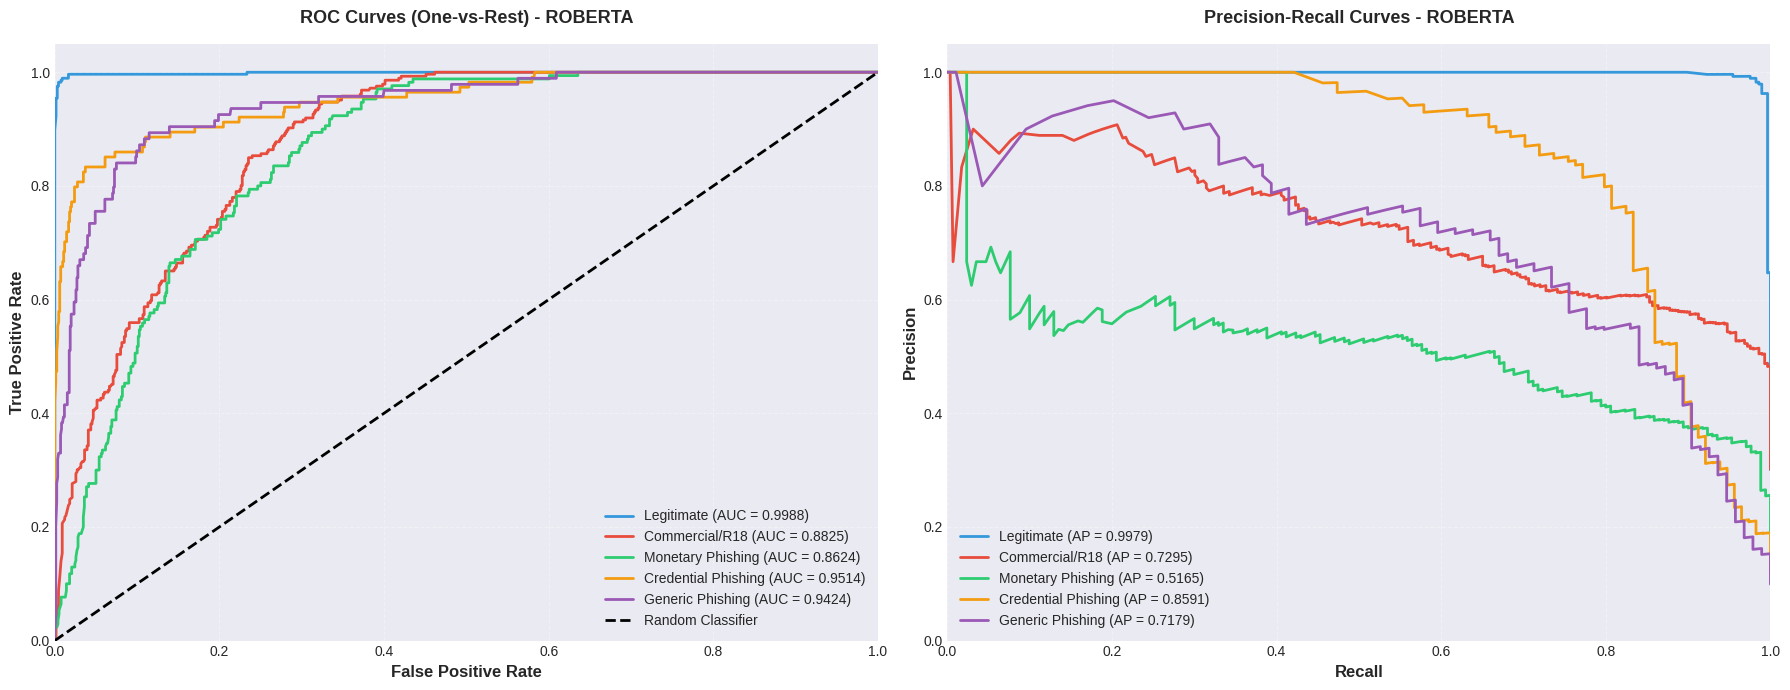


✓ Figure saved: /content/drive/MyDrive/thesis_results/roc_pr_curves.png

TABLE 5: ROC-AUC and Average Precision Scores

  Class Label                          ROC-AUC   Avg Precision     F1-Score
--------------------------------------------------------------------------------
      0 Legitimate                      0.9988          0.9979       0.9809
      1 Commercial/R18                  0.8825          0.7295       0.6409
      2 Monetary Phishing               0.8624          0.5165       0.5425
      3 Credential Phishing             0.9514          0.8591       0.8000
      4 Generic Phishing                0.9424          0.7179       0.6842
--------------------------------------------------------------------------------
AVG     Macro Average                   0.9275          0.7642       0.7297

Interpretation:
  - ROC-AUC: Overall discriminative ability (higher = better separation)
  - Avg Precision: Performance across all thresholds (higher = better for imbalanced)
  - F1-Sc

In [28]:
print('\n' + '=' * 80)
print('17.4 ROC AND PRECISION-RECALL CURVES')
print('=' * 80)

from sklearn.metrics import precision_recall_curve, average_precision_score, auc

# Binarize labels for one-vs-rest
y_test_bin = label_binarize(test_labels, classes=list(range(len(CLASS_LABELS))))

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for each class
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Plot 1: ROC Curves (One-vs-Rest)
ax1 = axes[0]

roc_auc_scores = {}
for i, color in enumerate(colors[:len(CLASS_LABELS)]):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[i] = roc_auc

    # Plot
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{CLASS_LABELS[i]} (AUC = {roc_auc:.4f})')

# Plot diagonal (random classifier)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title(f'ROC Curves (One-vs-Rest) - {best_model_name.upper()}',
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])

# Plot 2: Precision-Recall Curves
ax2 = axes[1]

ap_scores = {}
for i, color in enumerate(colors[:len(CLASS_LABELS)]):
    # Compute PR curve
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], test_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], test_probs[:, i])
    ap_scores[i] = ap

    # Plot
    ax2.plot(recall, precision, color=color, linewidth=2,
             label=f'{CLASS_LABELS[i]} (AP = {ap:.4f})')

ax2.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title(f'Precision-Recall Curves - {best_model_name.upper()}',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: {RESULTS_DIR}/roc_pr_curves.png")

# Numerical Tables
print('\n' + '=' * 80)
print('TABLE 5: ROC-AUC and Average Precision Scores')
print('=' * 80)
print(f"\n{'Class':>7} {'Label':<25} {'ROC-AUC':>12} {'Avg Precision':>15} {'F1-Score':>12}")
print('-' * 80)
for i in range(len(CLASS_LABELS)):
    print(f"{i:>7} {CLASS_LABELS[i]:<25} {roc_auc_scores[i]:>12.4f} "
          f"{ap_scores[i]:>15.4f} {test_metrics['per_class_f1'][i]:>12.4f}")
print('-' * 80)
print(f"{'AVG':<7} {'Macro Average':<25} "
      f"{np.mean(list(roc_auc_scores.values())):>12.4f} "
      f"{np.mean(list(ap_scores.values())):>15.4f} "
      f"{test_metrics['macro_f1']:>12.4f}")
print('=' * 80)

print('\nInterpretation:')
print('  - ROC-AUC: Overall discriminative ability (higher = better separation)')
print('  - Avg Precision: Performance across all thresholds (higher = better for imbalanced)')
print('  - F1-Score: Balance of precision and recall at optimal threshold')
print('=' * 80)

### 17.5 Data Distribution Analysis

Visualize the impact of hybrid balancing strategy on class distribution and analyze dataset characteristics.


17.5 DATA DISTRIBUTION ANALYSIS


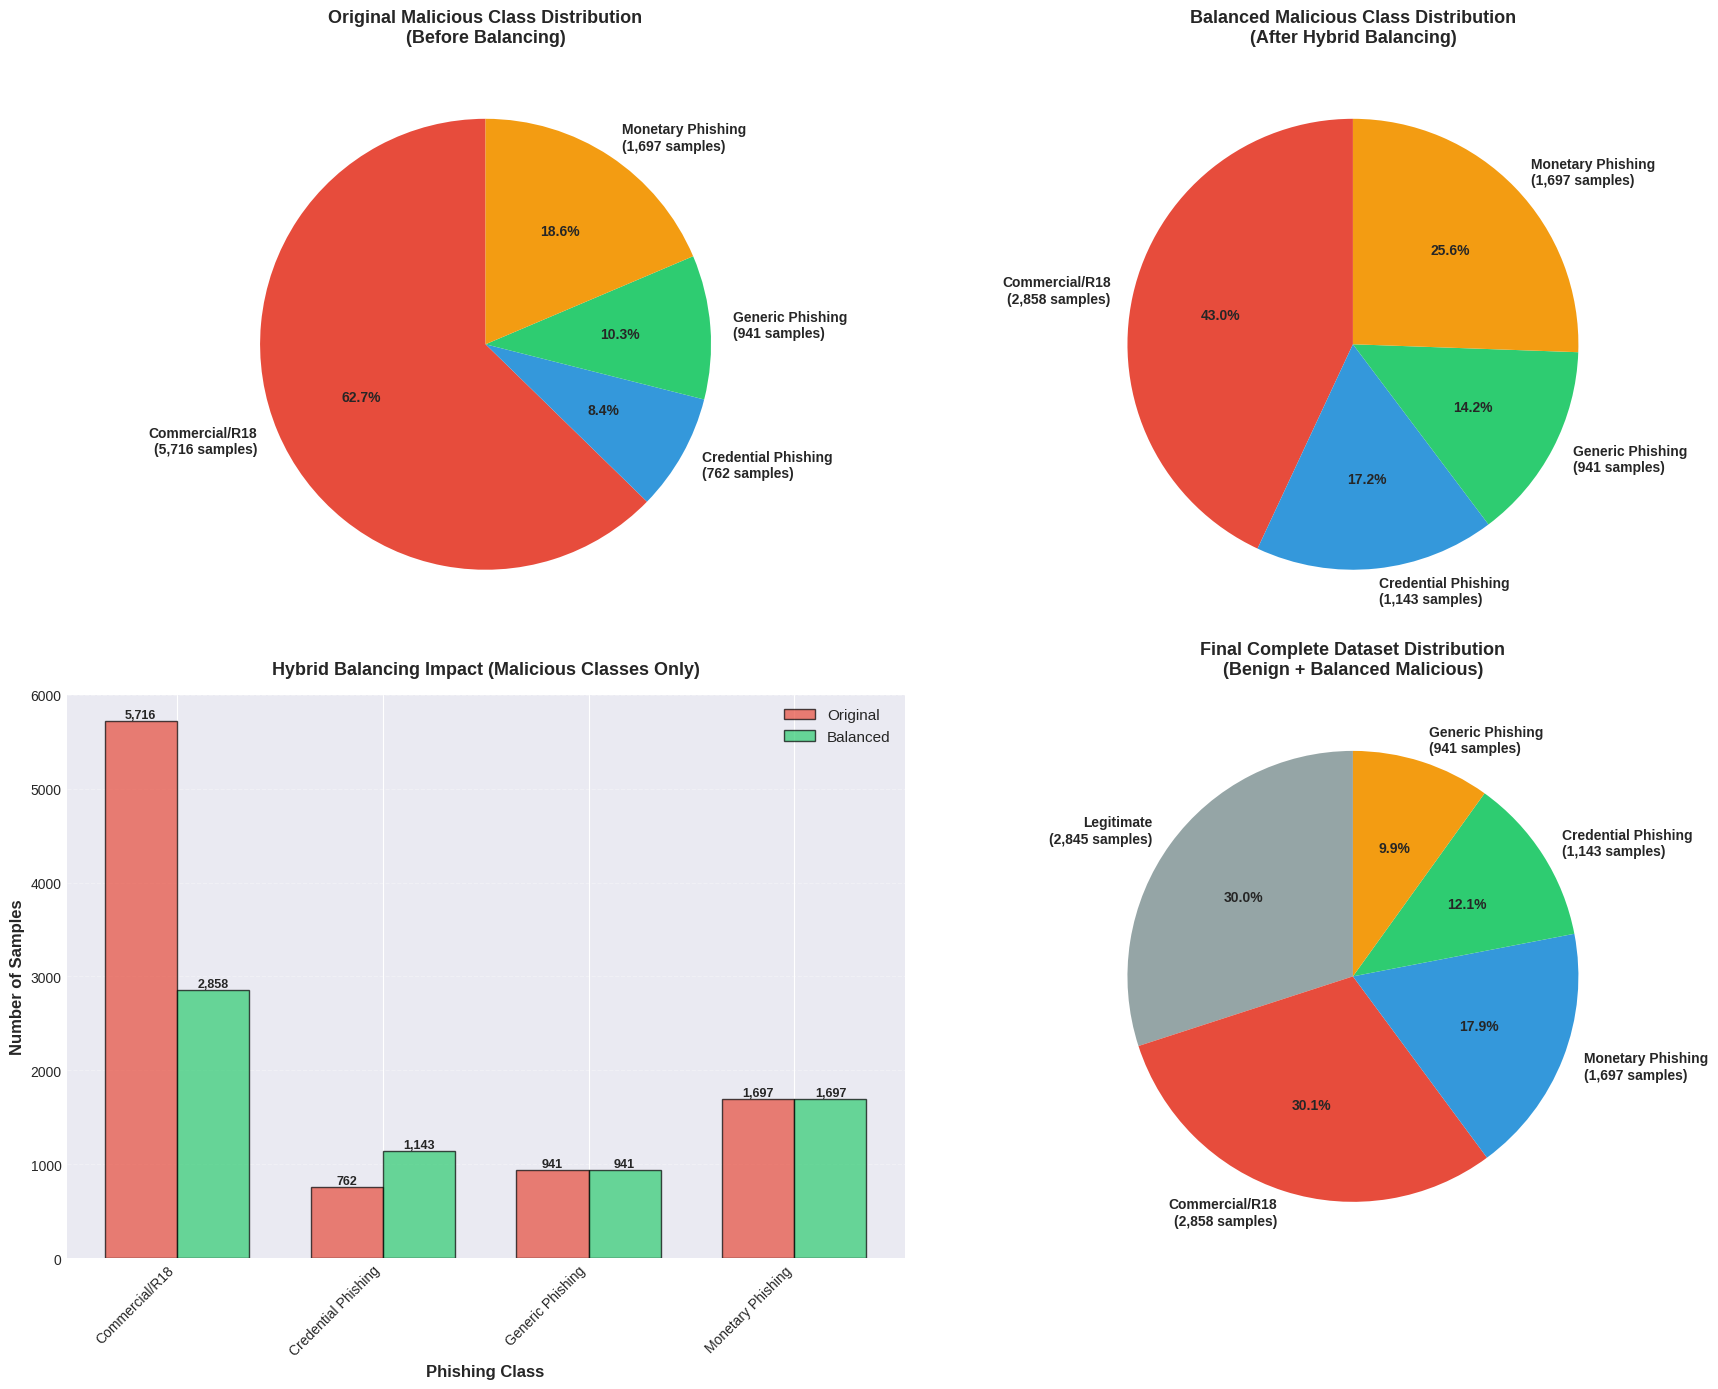


✓ Figure saved: /content/drive/MyDrive/thesis_results/data_distribution_analysis.png

TABLE 6: Hybrid Balancing Strategy Impact

Class                              Original     Balanced       Change               Method
------------------------------------------------------------------------------------------
Commercial/R18                        5,716        2,858       -2,858   Undersample (0.5x)
Credential Phishing                     762        1,143         +381    Oversample (1.5x)
Generic Phishing                        941          941           +0             Keep all
Monetary Phishing                     1,697        1,697           +0             Keep all
------------------------------------------------------------------------------------------
TOTAL MALICIOUS                       9,116        6,639       -2,477

TABLE 7: Complete Dataset Statistics

Split                       Total       Benign    Malicious        Ratio
---------------------------------------------------

In [29]:
print('\n' + '=' * 80)
print('17.5 DATA DISTRIBUTION ANALYSIS')
print('=' * 80)

original_malicious = {}
# Ensure we only look at malicious labels present in the dataframe
for label in sorted(annotated_df['label'].unique()):
    count = (annotated_df['label'] == label).sum()
    class_name = CLASS_LABELS.get(label, str(label))
    original_malicious[class_name] = count

# 2. Balanced Malicious (from CONFIG targets)
balanced_malicious = {}
for label, target in sorted(CONFIG['balance_targets'].items()):
    class_name = CLASS_LABELS.get(label, str(label))
    balanced_malicious[class_name] = target

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Original Malicious Distribution (Pie Chart)
ax1 = axes[0, 0]
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
# Ensure consistent ordering for colors
labels_ordered = sorted(original_malicious.keys())
values_ordered = [original_malicious[l] for l in labels_ordered]

wedges, texts, autotexts = ax1.pie(
    values_ordered,
    labels=labels_ordered,
    autopct='%1.1f%%',
    colors=colors_pie[:len(labels_ordered)],
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax1.set_title('Original Malicious Class Distribution\n(Before Balancing)',
              fontsize=13, fontweight='bold', pad=15)

# Add sample counts
for i, (text, count) in enumerate(zip(texts, values_ordered)):
    text.set_text(f"{text.get_text()}\n({count:,} samples)")

# Plot 2: Balanced Malicious Distribution (Pie Chart)
ax2 = axes[0, 1]
# Use same order
values_bal_ordered = [balanced_malicious.get(l, 0) for l in labels_ordered]

wedges2, texts2, autotexts2 = ax2.pie(
    values_bal_ordered,
    labels=labels_ordered,
    autopct='%1.1f%%',
    colors=colors_pie[:len(labels_ordered)],
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax2.set_title('Balanced Malicious Class Distribution\n(After Hybrid Balancing)',
              fontsize=13, fontweight='bold', pad=15)

for i, (text, count) in enumerate(zip(texts2, values_bal_ordered)):
    text.set_text(f"{text.get_text()}\n({count:,} samples)")

# Plot 3: Before/After Comparison (Bar Chart)
ax3 = axes[1, 0]

x = np.arange(len(labels_ordered))
width = 0.35

bars1 = ax3.bar(x - width/2, values_ordered, width, label='Original',
                color='#e74c3c', alpha=0.7, edgecolor='black')
bars2 = ax3.bar(x + width/2, values_bal_ordered, width, label='Balanced',
                color='#2ecc71', alpha=0.7, edgecolor='black')

ax3.set_xlabel('Phishing Class', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax3.set_title('Hybrid Balancing Impact (Malicious Classes Only)',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(labels_ordered, rotation=45, ha='right')
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Final Complete Dataset Distribution
ax4 = axes[1, 1]

final_dist = {}
for label in sorted(full_df['label'].unique()):
    count = (full_df['label'] == label).sum()
    final_dist[CLASS_LABELS[int(label)]] = count

colors_final = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#f39c12']
wedges3, texts3, autotexts3 = ax4.pie(
    final_dist.values(),
    labels=final_dist.keys(),
    autopct='%1.1f%%',
    colors=colors_final,
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax4.set_title('Final Complete Dataset Distribution\n(Benign + Balanced Malicious)',
              fontsize=13, fontweight='bold', pad=15)

for i, (text, count) in enumerate(zip(texts3, final_dist.values())):
    text.set_text(f"{text.get_text()}\n({count:,} samples)")

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/data_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: {RESULTS_DIR}/data_distribution_analysis.png")

# Numerical Tables
print('\n' + '=' * 80)
print('TABLE 6: Hybrid Balancing Strategy Impact')
print('=' * 80)
print(f"\n{'Class':<30} {'Original':>12} {'Balanced':>12} {'Change':>12} {'Method':>20}")
print('-' * 90)
for class_name in labels_ordered:
    orig = original_malicious[class_name]
    bal = balanced_malicious[class_name]
    change = bal - orig
    pct_change = (change / orig * 100) if orig > 0 else 0

    if change > 0:
        method = f"Oversample ({bal/orig:.1f}x)"
    elif change < 0:
        method = f"Undersample ({bal/orig:.1f}x)"
    else:
        method = "Keep all"

    print(f"{class_name:<30} {orig:>12,} {bal:>12,} {change:>+12,} {method:>20}")
print('-' * 90)
print(f"{'TOTAL MALICIOUS':<30} {sum(original_malicious.values()):>12,} "
      f"{sum(balanced_malicious.values()):>12,} "
      f"{sum(balanced_malicious.values())-sum(original_malicious.values()):>+12,}")
print('=' * 90)

print('\n' + '=' * 80)
print('TABLE 7: Complete Dataset Statistics')
print('=' * 80)
print(f"\n{'Split':<20} {'Total':>12} {'Benign':>12} {'Malicious':>12} {'Ratio':>12}")
print('-' * 70)
print(f"{'Original Data':<20} {len(full_df):>12,} "
      f"{(full_df['label']==0).sum():>12,} "
      f"{(full_df['label']!=0).sum():>12,} "
      f"{(full_df['label']==0).sum()/(full_df['label']!=0).sum():.2f}:1")
print(f"{'Training Set':<20} {len(X_train):>12,} "
      f"{(y_train==0).sum():>12,} "
      f"{(y_train!=0).sum():>12,} "
      f"{(y_train==0).sum()/(y_train!=0).sum():.2f}:1")
print(f"{'Validation Set':<20} {len(X_val):>12,} "
      f"{(y_val==0).sum():>12,} "
      f"{(y_val!=0).sum():>12,} "
      f"{(y_val==0).sum()/(y_val!=0).sum():.2f}:1")
print(f"{'Test Set':<20} {len(X_test):>12,} "
      f"{(y_test==0).sum():>12,} "
      f"{(y_test!=0).sum():>12,} "
      f"{(y_test==0).sum()/(y_test!=0).sum():.2f}:1")
print('=' * 70)

# Model Comparison


17.6 COMPREHENSIVE MODEL COMPARISON (Performance, Stability, Efficiency)


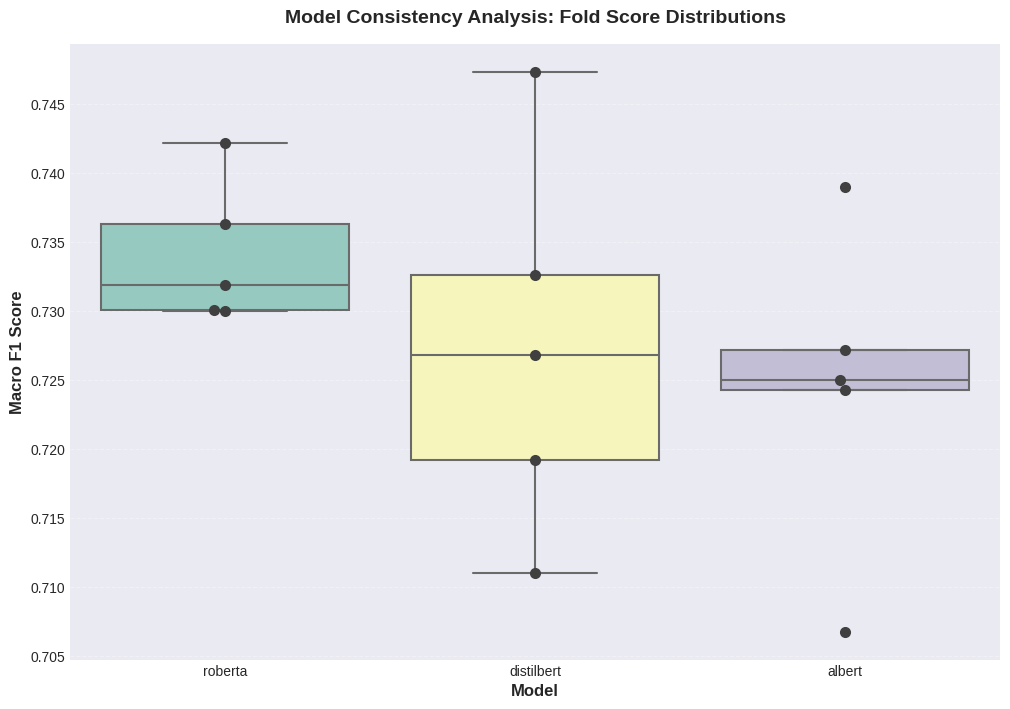


✓ Visualization saved to: /content/drive/MyDrive/thesis_results/model_comparison_comprehensive.png
✓ Summary table saved to: /content/drive/MyDrive/thesis_results/model_comparison_table.csv

MODEL PERFORMANCE LEADERBOARD
     Model  Mean F1  Std Dev  Best Fold  Worst Fold  Time (min)  Stability  Efficiency
   roberta   0.7341   0.0046     0.7422      0.7300      2.4562   215.4642      0.2989
distilbert   0.7274   0.0124     0.7474      0.7110      3.2670    80.9715      0.2227
    albert   0.7245   0.0103     0.7390      0.7068      1.0323    96.8711      0.7018

WINNER ANALYSIS
Ἴ6 PERFORMANCE WINNER: ROBERTA
   Reason: Highest Mean Macro F1 (0.7341)

Ὦ1️ RELIABILITY WINNER: ROBERTA
   Reason: Lowest Standard Deviation (0.0046)

⚡ EFFICIENCY WINNER: ALBERT
   Reason: Best trade-off between F1 score and training time (0.7018 F1/min)


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

print('\n' + '=' * 80)
print('17.6 COMPREHENSIVE MODEL COMPARISON (Performance, Stability, Efficiency)')
print('=' * 80)

# Ensure results directory exists
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print(f"Created directory: {RESULTS_DIR}")

# 1. Data Aggregation & 2. Metric Calculation
summary_data = []
fold_data = []

for model_name, results in cv_results.items():
    mean_f1 = results['mean_f1']
    std_f1 = results['std_f1']
    time_min = results['training_time'] / 60

    # Calculate derived metrics
    stability = 1 / std_f1 if std_f1 > 0 else np.nan  # Higher is better
    efficiency = mean_f1 / time_min if time_min > 0 else np.nan # F1 per minute

    summary_data.append({
        'Model': model_name,
        'Mean F1': mean_f1,
        'Std Dev': std_f1,
        'Best Fold': max(results['fold_scores']),
        'Worst Fold': min(results['fold_scores']),
        'Time (min)': time_min,
        'Stability': stability,
        'Efficiency': efficiency
    })

    # Prepare fold data for boxplot
    for score in results['fold_scores']:
        fold_data.append({
            'Model': model_name,
            'Fold Score': score
        })

# 3. DataFrame Creation
comparison_df = pd.DataFrame(summary_data).sort_values('Mean F1', ascending=False)
folds_df = pd.DataFrame(fold_data)

# 5. Visualization (Box Plot)
plt.figure(figsize=(12, 8))
sns.boxplot(x='Model', y='Fold Score', data=folds_df, palette='Set3', linewidth=1.5)
sns.swarmplot(x='Model', y='Fold Score', data=folds_df, color='.25', size=8)
plt.title('Model Consistency Analysis: Fold Score Distributions', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Save plot
plot_path = f'{RESULTS_DIR}/model_comparison_comprehensive.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Visualization saved to: {plot_path}")

# 6. Save Table
table_path = f'{RESULTS_DIR}/model_comparison_table.csv'
comparison_df.to_csv(table_path, index=False)
print(f"✓ Summary table saved to: {table_path}")

# 7. Textual Analysis & 8. Display
print('\n' + '=' * 80)
print('MODEL PERFORMANCE LEADERBOARD')
print('=' * 80)
print(comparison_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))

print('\n' + '=' * 80)
print('WINNER ANALYSIS')
print('=' * 80)

# Performance Winner
perf_winner = comparison_df.loc[comparison_df['Mean F1'].idxmax()]
print(f"Ἴ6 PERFORMANCE WINNER: {perf_winner['Model'].upper()}")
print(f"   Reason: Highest Mean Macro F1 ({perf_winner['Mean F1']:.4f})")

# Reliability Winner
rel_winner = comparison_df.loc[comparison_df['Std Dev'].idxmin()]
print(f"\nὮ1️ RELIABILITY WINNER: {rel_winner['Model'].upper()}")
print(f"   Reason: Lowest Standard Deviation ({rel_winner['Std Dev']:.4f})")

# Efficiency Winner
eff_winner = comparison_df.loc[comparison_df['Efficiency'].idxmax()]
print(f"\n⚡ EFFICIENCY WINNER: {eff_winner['Model'].upper()}")
print(f"   Reason: Best trade-off between F1 score and training time ({eff_winner['Efficiency']:.4f} F1/min)")
print('=' * 80)

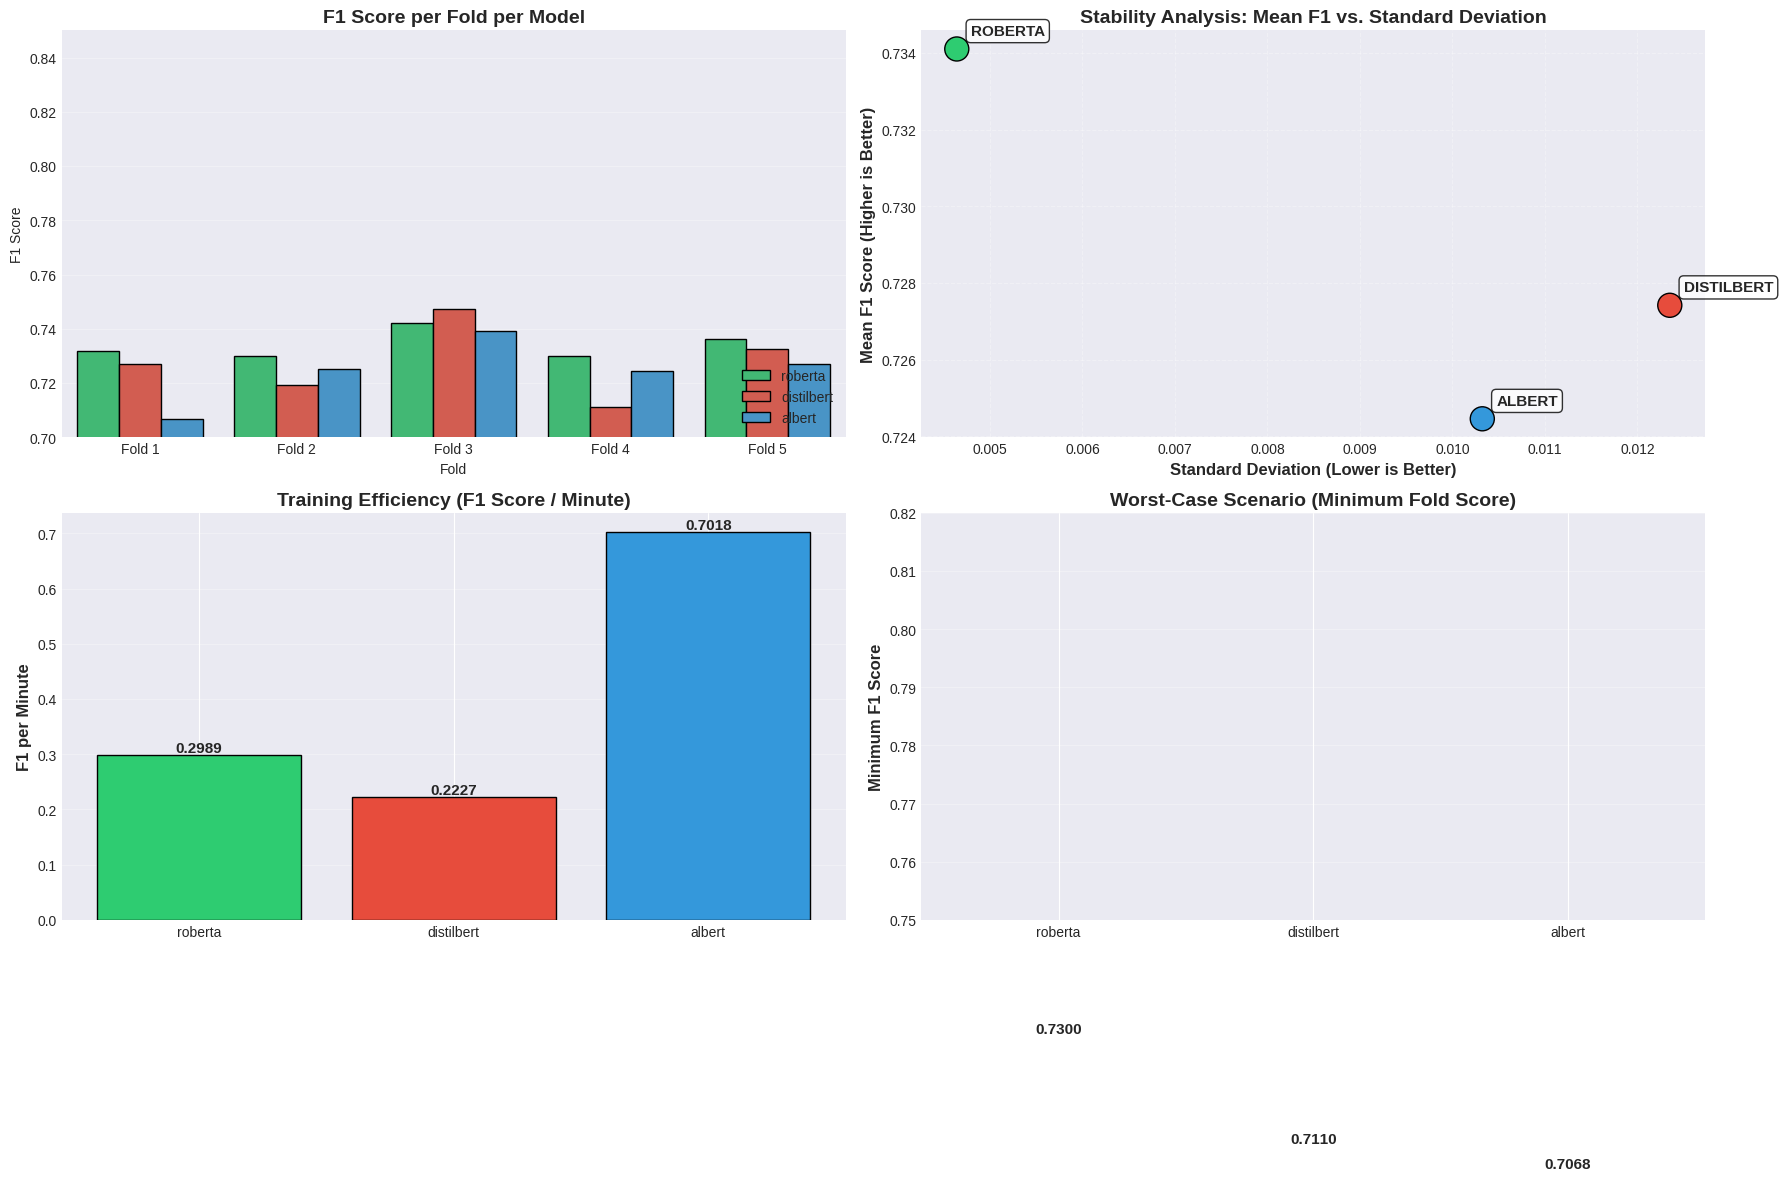


✓ Additional comparison graphs saved to: /content/drive/MyDrive/thesis_results/model_comparison_additional.png


In [31]:
# Ensure results directory exists (should already exist)
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Prepare Data
models = []
folds = []
scores = []
mean_f1s = []
std_f1s = []
efficiencies = []
min_scores = []
colors_map = {'roberta': '#2ecc71', 'distilbert': '#e74c3c', 'albert': '#3498db'}

for model_name, results in cv_results.items():
    # For Grouped Bar Chart
    for i, score in enumerate(results['fold_scores']):
        models.append(model_name)
        folds.append(f"Fold {i+1}")
        scores.append(score)

    # For other charts
    mean_f1 = results['mean_f1']
    std_f1 = results['std_f1']
    time_min = results['training_time'] / 60
    efficiency = mean_f1 / time_min
    min_score = min(results['fold_scores'])

    mean_f1s.append(mean_f1)
    std_f1s.append(std_f1)
    efficiencies.append(efficiency)
    min_scores.append(min_score)

df_folds = pd.DataFrame({'Model': models, 'Fold': folds, 'F1 Score': scores})
model_names_unique = list(cv_results.keys())

# 2. Create Plot Grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graph 1: Grouped Bar Chart (F1 per Fold)
sns.barplot(x='Fold', y='F1 Score', hue='Model', data=df_folds, ax=axes[0, 0], palette=colors_map, edgecolor='black')
axes[0, 0].set_title('F1 Score per Fold per Model', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0.7, 0.85]) # Zoom in to see differences
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].legend(loc='lower right')

# Graph 2: Scatter Plot (Mean F1 vs Std Dev)
# Note: Lower Std Dev is better (more stable)
colors = [colors_map[m] for m in model_names_unique]
axes[0, 1].scatter(std_f1s, mean_f1s, s=300, c=colors, edgecolor='black', zorder=5)
axes[0, 1].set_title('Stability Analysis: Mean F1 vs. Standard Deviation', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Standard Deviation (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Mean F1 Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# Add labels to points
for i, txt in enumerate(model_names_unique):
    axes[0, 1].annotate(txt.upper(), (std_f1s[i], mean_f1s[i]),
                       xytext=(10, 10), textcoords='offset points',
                       fontsize=11, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

# Graph 3: Bar Chart (Training Efficiency)
# F1 Score per Minute of Training
bars = axes[1, 0].bar(model_names_unique, efficiencies, color=colors, edgecolor='black')
axes[1, 0].set_title('Training Efficiency (F1 Score / Minute)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('F1 per Minute', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Graph 4: Bar Chart (Minimum Fold Score - Worst Case)
bars_min = axes[1, 1].bar(model_names_unique, min_scores, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Worst-Case Scenario (Minimum Fold Score)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Minimum F1 Score', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0.75, 0.82]) # Zoom in
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars_min:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Save and Show
plt.tight_layout()
save_path = f'{RESULTS_DIR}/model_comparison_additional.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Additional comparison graphs saved to: {save_path}")



WORD CLOUD ANALYSIS PER CLASS
Using full_df (balanced dataset) for text source...

Generating word clouds for 5 classes...


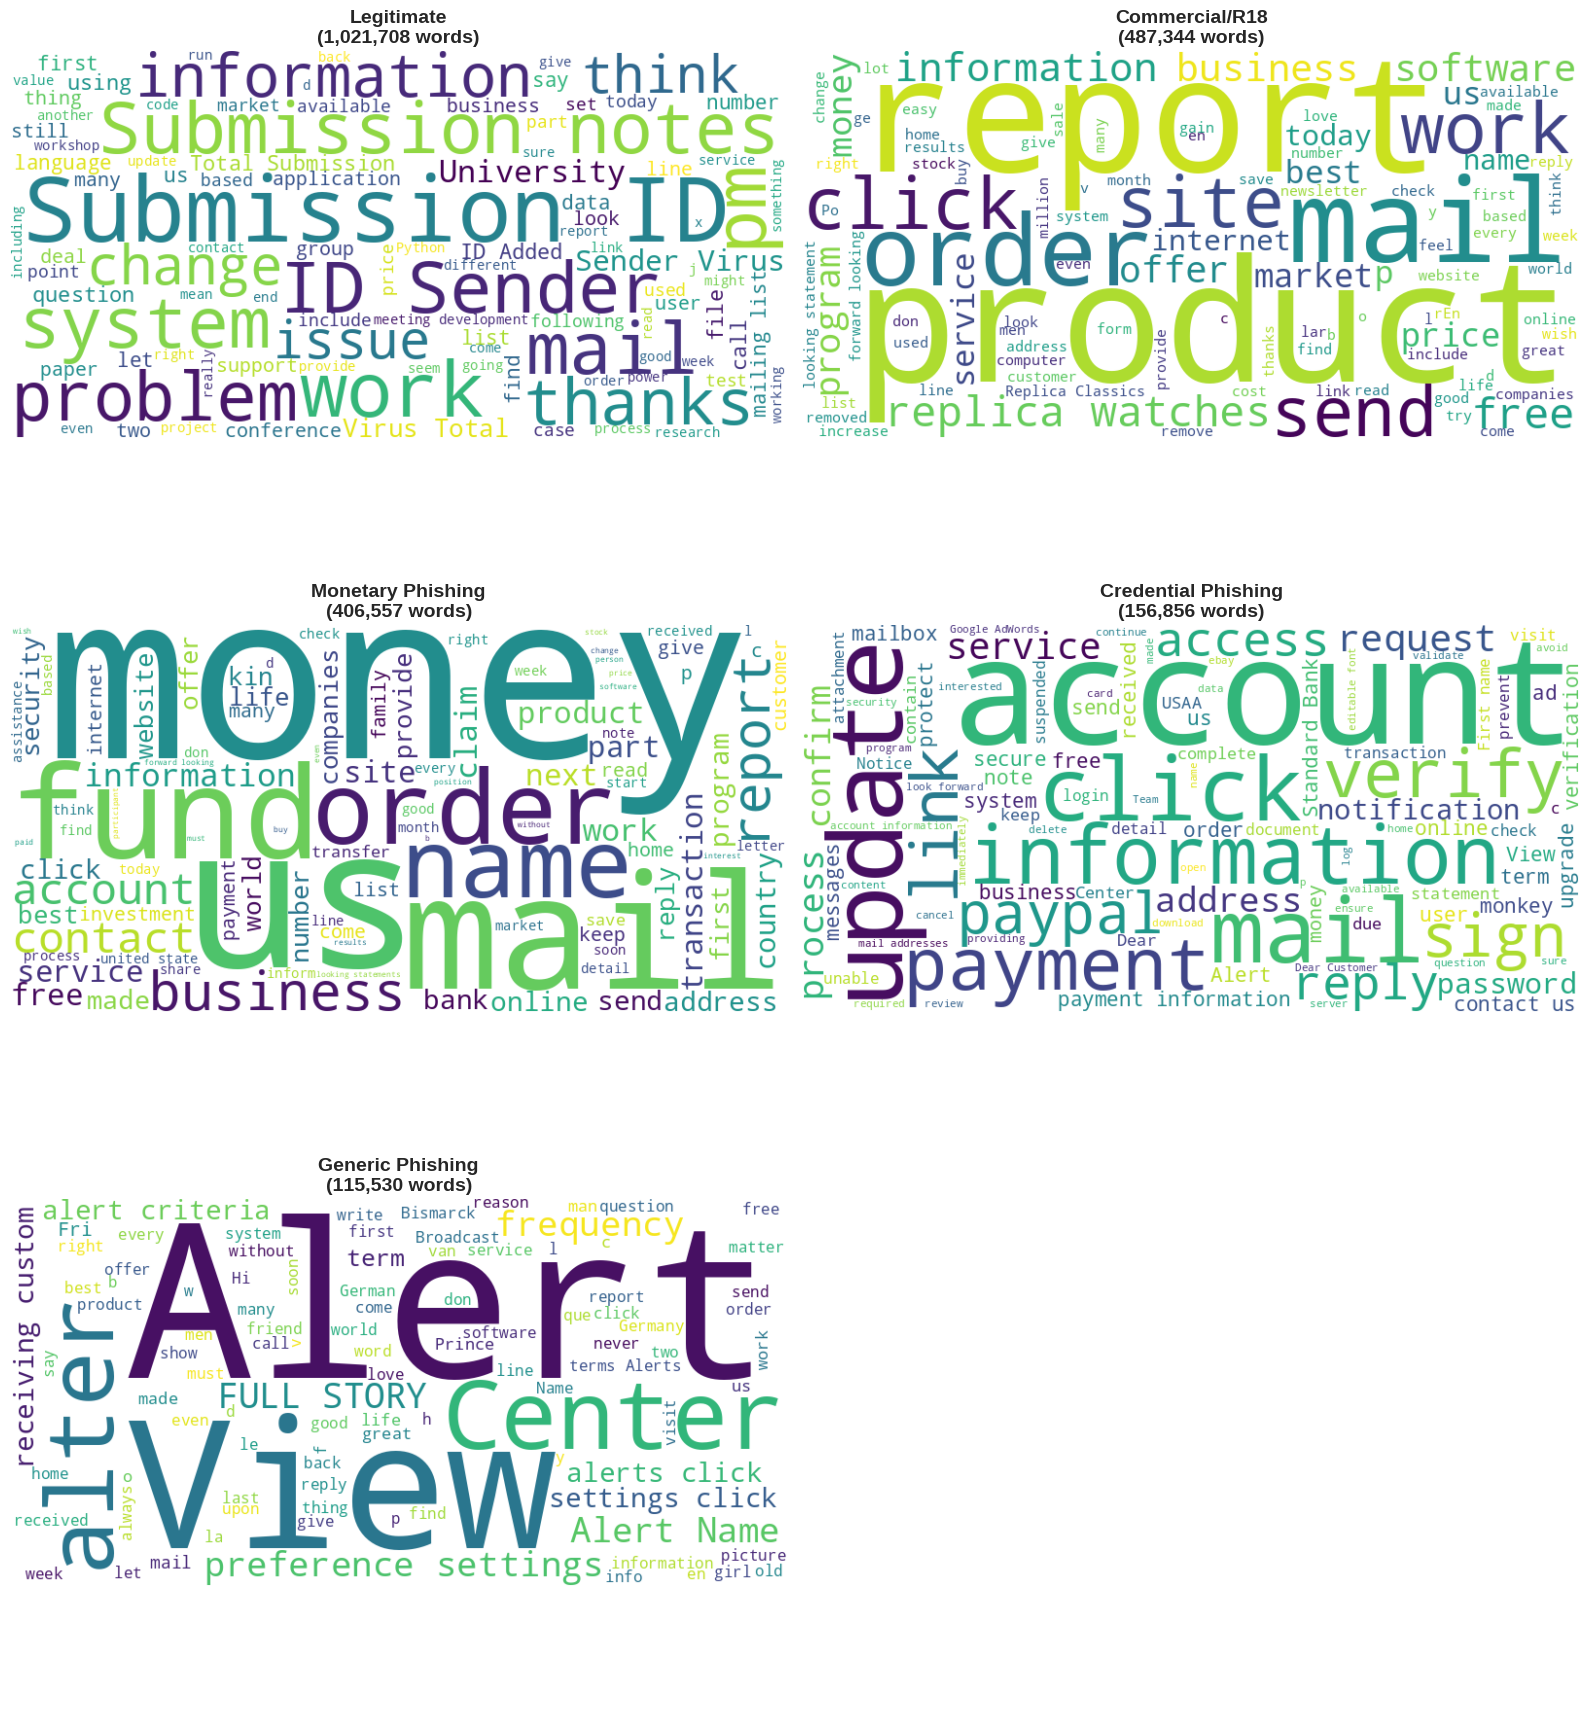

✓ Word clouds saved to: /content/drive/MyDrive/thesis_results/class_wordclouds.png

TOP 10 KEYWORDS PER CLASS
Class                     Top Keywords                                      
--------------------------------------------------------------------------------
Legitimate                Submission ID, work, pm, mail, ID Sender, Submission notes, system, problem, thanks, information
Commercial/R18            product, report, mail, order, click, work, site, send, replica watches, free
Monetary Phishing         money, us, mail, fund, order, name, business, report, account, contact
Credential Phishing       account, update, mail, click, information, payment, verify, link, sign, paypal
Generic Phishing          Alert, View, Center, alter, preference settings, frequency, Alert Name, FULL STORY, settings click, alert criteria


In [32]:
# Install wordcloud library
!pip install -q wordcloud

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd
import os

print('\n' + '=' * 80)
print('WORD CLOUD ANALYSIS PER CLASS')
print('=' * 80)

# Define custom stopwords for emails
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    '_', '__', '___', 's', 'u', 'e', 'de', 'm', 'n', 't', 'subject', 're', 'fw', 'fwd', 'cc', 'to', 'from', 'date', 'sent',
    'http', 'https', 'www', 'com', 'org', 'net', 'html', 'body', 'image', 'will', 'YEAR', 'year', 'URL', 'url', 'new', 'one', 'use', 'time',
    'EMAIL', 'email', 'now', 'company', 'Company', 'make', 'way', 'day', 'know', 'see', 'take', 'said', 'may',
    'go', 'want', 'well', 'much', 'also', 'would', 'could', 'people',
    'get', 'like', 'just', 'thank', 'please', 'help', 'need',
    'enron', 'ect', 'hou', 'original', 'message', 'receive', 'unsubscribe', 'result', 'Aug', 'Rights', 'Reserved',
    'manage', 'agreed', 'privacy', 'policy', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'nbsp', 'http', 'https', 'www', 'com', 'org', 'html', 'htm',
    'subject', 'from', 'sent', 'to', 're', 'fw', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'
])

# Aggregate text per class
class_texts = {}

# Source Data Selection
if 'full_df' in locals():
    print("Using full_df (balanced dataset) for text source...")
    source_df = full_df
elif 'annotated_df' in locals() and 'benign_df' in locals():
    print("Using annotated_df + benign_df for text source...")
    # Combine for visualization
    source_df = pd.concat([benign_df, annotated_df], ignore_index=True)
    if 'label' not in source_df.columns:
         # Ensure labels are consistent if falling back
         pass
else:
    print("⚠️ Dataframes not found. Cannot generate word clouds.")
    source_df = None

if source_df is not None:
    # Group text by class
    for label in sorted(source_df['label'].unique()):
        # Get all text for this class
        texts = source_df[source_df['label'] == label]['text_cleaned'].astype(str)
        class_texts[label] = " ".join(texts.tolist())

    # Create subplots
    n_classes = len(class_texts)
    cols = 2
    rows = (n_classes + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 6*rows))
    axes = axes.flatten()

    print(f"\nGenerating word clouds for {n_classes} classes...")

    # Generate and Plot
    for i, label in enumerate(sorted(class_texts.keys())):
        class_name = CLASS_LABELS.get(label, f"Class {label}")
        text = class_texts[label]

        # Generate WordCloud
        wc = WordCloud(
            width=800, height=400,
            background_color='white',
            max_words=100,
            stopwords=custom_stopwords,
            colormap='viridis',
            contour_width=1,
            contour_color='steelblue'
        ).generate(text)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"{class_name}\n({len(text.split()):,} words)", fontsize=14, fontweight='bold')
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    save_path = f'{RESULTS_DIR}/class_wordclouds.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✓ Word clouds saved to: {save_path}")

    # Generate Keyword Table
    print('\n' + '=' * 80)
    print('TOP 10 KEYWORDS PER CLASS')
    print('=' * 80)
    print(f"{'Class':<25} {'Top Keywords':<50}")
    print('-' * 80)

    for label in sorted(class_texts.keys()):
        class_name = CLASS_LABELS.get(label, f"Class {label}")

        # Use WordCloud's internal frequency calculation
        wc = WordCloud(stopwords=custom_stopwords).process_text(class_texts[label])

        # Sort by frequency
        top_words = sorted(wc.items(), key=lambda x: x[1], reverse=True)[:10]
        words_str = ", ".join([w for w, freq in top_words])

        print(f"{class_name:<25} {words_str}")
    print('=' * 80)